# ENVIRONMENT

In [1]:
!nvidia-smi
!lscpu
!free -h
!cat /etc/os-release
!df -h

Thu May 14 23:24:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# CONFIGURATIONS

In [2]:
SEED = 42
BATCH_SIZE = 64
LR = 1e-3
WEIGHT_DECAY = 0.05
FL_GAMMA = 2.0
NUM_WORKERS = 3
PATIENCE = 10
N_EPOCHS = 50

INPUT_DATASETS_ROOT = "/kaggle/input/datasets/angelogoes/tilda-hku-patched-dataset"
EXPERIMENTS_ROOT = "./experiments"

# LIBRARIES

In [3]:
import os
import gc
import json
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
torch.set_float32_matmul_precision('medium')

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, Callback
from pytorch_lightning.loggers import CSVLogger

import torchmetrics
from torchmetrics.classification import (
    MulticlassF1Score, MulticlassAccuracy, MulticlassPrecision, MulticlassRecall,
    BinaryF1Score, BinaryAccuracy, BinaryPrecision, BinaryRecall
)
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm

from huggingface_hub.utils import disable_progress_bars
disable_progress_bars()

# import warnings
# import logging

# os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3" 
# os.environ["GRPC_VERBOSITY"] = "ERROR"
# os.environ["HF_HUB_OFFLINE"] = "1"
# warnings.filterwarnings("ignore", category=DeprecationWarning)
# warnings.filterwarnings("ignore", category=UserWarning, module="pytorch_lightning")
# logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
# warnings.filterwarnings("ignore", message=r".*isinstance\(treespec, LeafSpec\).*")
# warnings.filterwarnings("ignore", category=UserWarning)
# warnings.filterwarnings("ignore", category=DeprecationWarning)

def set_seed(seed: int = 42) -> None:
    # Set a fixed value for the hash seed
    os.environ["PYTHONHASHSEED"] = str(seed)
    # Set seed for PyTorch
    torch.manual_seed(seed)
    # Set seed for CUDA (if using GPUs)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # For multi-GPU setups
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Set seed for Python's random module
    random.seed(seed)
    # Set seed for NumPy
    np.random.seed(seed)
    #tf.random.set_seed(seed) # set random seed for TensorFlow
    pl.seed_everything(seed, workers=True)
    print(f"[{datetime.now().strftime('%H:%M:%S')}] Seed set as {seed}")

In [4]:
!pip freeze > requirements.txt
set_seed(SEED)

Seed set to 42


[23:25:31] Seed set as 42


# UTILITIES

## TRANFORMS & DATASET

In [5]:
class MulticlassFocalLoss(nn.Module):
    def __init__(
        self,
        alpha=None,
        gamma=FL_GAMMA,
        reduction='mean',
        ignore_index=-100
    ):
        super().__init__()

        self.gamma = gamma
        self.reduction = reduction
        self.ignore_index = ignore_index

        if alpha is not None:
            alpha = torch.tensor(alpha, dtype=torch.float32)
            if alpha.ndim != 1:
                raise ValueError("alpha must be 1D")
            self.register_buffer("alpha", alpha)
        else:
            self.alpha = None

    def forward(self, inputs, targets):

        valid_mask = targets != self.ignore_index
        targets_clean = targets.clone()
        targets_clean[~valid_mask] = 0
        log_probs = F.log_softmax(inputs, dim=1)
        log_pt = log_probs.gather(1, targets_clean.unsqueeze(1)).squeeze(1)
        pt = log_pt.exp()
        pt = pt.clamp(min=1e-8, max=1.0 - 1e-8)
        focal_term = (1 - pt) ** self.gamma
        loss = -focal_term * log_pt

        if self.alpha is not None:
            if self.alpha.numel() != inputs.size(1):
                raise ValueError(
                    f"alpha has {self.alpha.numel()} elements "
                    f"but expected {inputs.size(1)}"
                )
            alpha_t = self.alpha[targets_clean]
            loss = alpha_t * loss

        loss = loss[valid_mask]
        if self.reduction == 'mean': return loss.mean()
        elif self.reduction == 'sum': return loss.sum()

        return loss

def get_transforms(model_name, is_training=True):
    """
    Treino: Albumentations (D4 Geometria) + Timm Normalize
    Eval: Apenas Timm (Resize + Normalize)
    """
    temp_model = timm.create_model(model_name, pretrained=False, num_classes=0)
    data_config = timm.data.resolve_model_data_config(temp_model)
    mean, std = data_config['mean'], data_config['std']
    input_size = data_config['input_size'][-1]
    
    if is_training:
        return A.Compose([
            A.Resize(input_size, input_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.Normalize(mean=mean, std=std),
            ToTensorV2()
        ]), input_size
    else:
        return A.Compose([
            A.Resize(input_size, input_size),
            A.Normalize(mean=mean, std=std),
            ToTensorV2()
        ]), input_size

class NPZTextileDataset(Dataset):
    def __init__(self, X, y_multi, transform=None):
        """Recebe arrays NumPy carregados do disco"""
        self.X = X
        self.y_multi = y_multi
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx] # (H, W, 3) do NPZ
        
        if self.transform:
            # Albumentations espera numpy arrays
            augmented = self.transform(image=image)
            image = augmented['image']
            
        label = torch.tensor(self.y_multi[idx], dtype=torch.long)
        return image, label

## MODEL

In [6]:
class TextileLightningModel(pl.LightningModule):
    def __init__(self, model_name, num_classes, experiment_type, class_weights=None, lr=LR):
        super().__init__()
        self.save_hyperparameters(ignore=['class_weights'])
        self.lr = lr
        
        # Carrega o modelo pre-treinado
        self.model = timm.create_model(model_name, pretrained=True, num_classes=num_classes, in_chans=3)
        
        # Define a Loss
        if experiment_type == "wce" and class_weights is not None:
            weights = torch.tensor(class_weights, dtype=torch.float32)
            self.criterion = nn.CrossEntropyLoss(weight=weights)
        elif experiment_type == "focal_loss" and class_weights is not None:
            self.criterion = MulticlassFocalLoss(alpha=class_weights, gamma=FL_GAMMA)
        else:
            self.criterion = nn.CrossEntropyLoss()
            
        # Métricas - Multiclasse (Ignorando 'good' para certas métricas se desejar, mas aqui usamos tudo macro)
        self.multi_f1 = MulticlassF1Score(num_classes=num_classes, average='macro')
        self.multi_acc = MulticlassAccuracy(num_classes=num_classes, average='micro')
        
        # Métricas - Binário (Defeito vs Good)
        self.bin_f1 = BinaryF1Score()
        self.bin_acc = BinaryAccuracy()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        inputs, labels = batch
        logits = self(inputs)
        loss = self.criterion(logits, labels)
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        inputs, labels = batch
        logits = self(inputs)
        loss = self.criterion(logits, labels)
        
        # Probs e Preds
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        
        # Conversão Binária (0 = good, >0 = defeito)
        bin_labels = (labels > 0).long()
        bin_probs = probs[:, 1:].sum(dim=1)
        
        # Atualiza métricas
        self.multi_f1(preds, labels)
        self.multi_acc(preds, labels)
        self.bin_f1(bin_probs, bin_labels)
        self.bin_acc(bin_probs, bin_labels)
        
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_f1_macro', self.multi_f1, on_epoch=True, prog_bar=True)
        self.log('val_acc_multi', self.multi_acc, on_epoch=True)
        self.log('val_f1_bin', self.bin_f1, on_epoch=True)
        self.log('val_acc_bin', self.bin_acc, on_epoch=True)

    def configure_optimizers(self):
        # AdamW é o padrão para modelos ViT e modernos do TIMM
        optimizer = optim.AdamW(self.parameters(), lr=self.lr, weight_decay=WEIGHT_DECAY)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=self.trainer.max_epochs)
        return [optimizer], [scheduler]

## GENERAL

In [7]:
def load_npz_and_undersample(npz_path, undersample_ratio=None):
    """Carrega dados e faz undersampling de exemplos bons (classe 0) se solicitado."""
    data = np.load(npz_path)
    X, y = data['X'], data['y_multi']
    
    if undersample_ratio:
        idx_defects = np.where(y > 0)[0]
        idx_goods = np.where(y == 0)[0]
        
        target_good = int(len(idx_defects) * undersample_ratio)
        if target_good < len(idx_goods):
            np.random.seed(42)
            idx_goods = np.random.choice(idx_goods, target_good, replace=False)
            
        final_indices = np.concatenate([idx_defects, idx_goods])
        np.random.shuffle(final_indices)
        X, y = X[final_indices], y[final_indices]
        
    return X, y

def get_predictions_and_metrics(model, loader, device='cuda'):
    model.eval()
    model.to(device)
    y_true, y_pred = [], []
    
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            preds = torch.argmax(model(x), dim=1)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    y_true_bin, y_pred_bin = (y_true > 0).astype(int), (y_pred > 0).astype(int)
    
    metrics = {
        'F1 Macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'F1 Weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0), # NOVO
        'Precision Macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall Macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'Binary Accuracy': accuracy_score(y_true_bin, y_pred_bin)
    }
    return metrics, y_true, y_pred, y_true_bin, y_pred_bin

def plot_fold_metrics(csv_path, fold_num):
    if not os.path.exists(csv_path):
        print(f"[{datetime.now().strftime('%H:%M:%S')}] ⚠️ Log não encontrado: {csv_path}")
        return

    df = pd.read_csv(csv_path)
    cols = df.columns.tolist() # Vemos o que o CSV tem de verdade
    
    # 1. Gráfico de Perdas (Loss)
    train_loss = df.dropna(subset=['train_loss']).groupby('epoch')['train_loss'].mean()
    
    # Pegamos val_loss apenas se existir
    val_loss_col = [c for c in ['val_loss'] if c in cols]
    val_loss_df = df.dropna(subset=val_loss_col).groupby('epoch')[val_loss_col].mean() if val_loss_col else pd.DataFrame()

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    if not train_loss.empty:
        axes[0].plot(train_loss.index, train_loss.values, label='Train Loss', color='blue', alpha=0.6)
    if not val_loss_df.empty:
        axes[0].plot(val_loss_df.index, val_loss_df['val_loss'], label='Val Loss', color='red', marker='o')
    
    axes[0].set_title(f'Fold {fold_num} - Losses')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].xaxis.set_major_locator(MaxNLocator(integer=True)) 
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # 2. Gráfico de Performance (Métricas)
    # Lista de desejos:
    target_metrics = ['val_acc_bin', 'val_f1_weighted', 'val_f1_macro']
    # O que realmente encontramos no CSV:
    available_metrics = [m for m in target_metrics if m in cols]
    
    if available_metrics:
        val_perf_df = df.dropna(subset=[available_metrics[0]]).groupby('epoch')[available_metrics].mean()
        
        colors = {'val_acc_bin': 'gray', 'val_f1_weighted': 'green', 'val_f1_macro': 'purple'}
        for m in available_metrics:
            axes[1].plot(val_perf_df.index, val_perf_df[m], label=m, color=colors.get(m), linewidth=2)
    
    axes[1].set_title(f'Fold {fold_num} - Performance')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Score')
    axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

def plot_final_model_metrics(csv_path):
    """Lê o log do modelo final e plota a curva de aprendizado (apenas treino)."""
    if not os.path.exists(csv_path):
        print(f"[{datetime.now().strftime('%H:%M:%S')}] ⚠️ Log não encontrado para plotagem do modelo final: {csv_path}")
        return

    df = pd.read_csv(csv_path)

    # Agrupar por época para a curva de treino
    train_loss = df.dropna(subset=['train_loss']).groupby('epoch')['train_loss'].mean()

    plt.figure(figsize=(8, 5))

    if not train_loss.empty:
        plt.plot(train_loss.index, train_loss.values, label='Train Loss (100% Data)', color='darkblue', linewidth=2, marker='o')
    
    plt.title('Modelo Final (Sexto Elemento) - Curva de Treinamento')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    
    # Forçar números inteiros no eixo X
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True)) 
    
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def evaluate_holdout_with_bootstrapping(model, test_loader, device='cuda', n_iterations=1000, class_names=None):
    print(f"\n[{datetime.now().strftime('%H:%M:%S')}] 🔮 Extraindo predições do Holdout Test...")
    
    exact_metrics, y_true, y_pred, y_true_bin, y_pred_bin = get_predictions_and_metrics(model, test_loader, device)
    
    # 1. Relatório Detalhado (O Classification Report já traz o Weighted por padrão na última linha)
    print("\n" + "="*65)
    print("📊 RELATÓRIO DE CLASSIFICAÇÃO DETALHADO (HOLDOUT EXATO)")
    print("="*65)
    
    unique_classes = np.unique(np.concatenate((y_true, y_pred)))
    target_names = class_names if class_names else [f"Classe {int(i)}" for i in unique_classes]
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))
    
    # 2. Plotagem das Matrizes (Código de rotação mantido)
    cm_abs = confusion_matrix(y_true, y_pred)
    cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    for i, (cm, title, fmt) in enumerate(zip([cm_abs, cm_norm], ['Absoluta', 'Normalizada'], ['d', '.2f'])):
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
        disp.plot(ax=axes[i], cmap='Blues', values_format=fmt, colorbar=False)
        fig.colorbar(disp.im_, ax=axes[i], shrink=0.8)
        axes[i].set_title(f'Matriz de Confusão ({title})')
        plt.setp(axes[i].get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
        plt.setp(axes[i].get_yticklabels(), rotation=45, va='center')

    plt.tight_layout()
    plt.show()

    # 3. Bootstrapping com F1 Weighted
    print(f"\n[{datetime.now().strftime('%H:%M:%S')}] 🎲 Iniciando Bootstrapping ({n_iterations} iterações)...")
    
    boot_metrics = {
        'F1 Macro': [], 
        'F1 Weighted': [],
        'Precision Macro': [], 
        'Recall Macro': [], 
        'Binary Accuracy': []
    }
    
    n_size = len(y_true)
    
    for _ in range(n_iterations):
        idx = np.random.choice(n_size, size=n_size, replace=True)
        y_t_boot, y_p_boot = y_true[idx], y_pred[idx]
        y_t_bin_boot, y_p_bin_boot = y_true_bin[idx], y_pred_bin[idx]
        
        boot_metrics['F1 Macro'].append(f1_score(y_t_boot, y_p_boot, average='macro', zero_division=0))
        boot_metrics['F1 Weighted'].append(f1_score(y_t_boot, y_p_boot, average='weighted', zero_division=0))
        boot_metrics['Precision Macro'].append(precision_score(y_t_boot, y_p_boot, average='macro', zero_division=0))
        boot_metrics['Recall Macro'].append(recall_score(y_t_boot, y_p_boot, average='macro', zero_division=0))
        boot_metrics['Binary Accuracy'].append(accuracy_score(y_t_bin_boot, y_p_bin_boot))
        
    print("\n" + "="*75)
    print("🏆 RESULTADOS FINAIS NO HOLDOUT (BOOTSTRAPPING - 95% CI) 🏆")
    print("="*75)
    
    res = {}
    for name in boot_metrics.keys():
        arr = np.array(boot_metrics[name])
        res[name] = {
            'mean': np.mean(arr), 
            'ci_lower': np.percentile(arr, 2.5), 
            'ci_upper': np.percentile(arr, 97.5), 
            'exact': exact_metrics[name]
        }
        print(f"🔹 {name:<18}: {res[name]['mean']:.4f} (95% CI: [{res[name]['ci_lower']:.4f}, {res[name]['ci_upper']:.4f}])  | Exato: {res[name]['exact']:.4f}")
    
    print("="*75 + "\n")
    return res

def run_lightning_experiment(
    dataset_name="HKU", 
    resolution=64,
    model_name='fastvit_t8.apple_in1k', 
    experiment_type="wce", 
    undersample_ratio=None, 
    num_epochs=50, 
    batch_size=64
):
    print(f"\n{'='*60}")
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] 🚀 INICIANDO: {dataset_name} | {resolution}px | {model_name} | {experiment_type.upper()}")
    print(f"{'='*60}")
    
    base_dir = f"{INPUT_DATASETS_ROOT}/npz_{dataset_name.lower()}_{resolution}"
    
    # Cria uma string com o ratio (ex: "_ratio5") se ele existir, senão fica vazia
    ratio_str = f"_ratio{undersample_ratio}" if undersample_ratio is not None else ""
    
    # Adiciona o ratio_str no nome da pasta
    output_dir = f"{EXPERIMENTS_ROOT}/{dataset_name}_{resolution}_{experiment_type}{ratio_str}_{model_name}"
    # =====================
    
    os.makedirs(output_dir, exist_ok=True)
    
    best_epochs = []

    cv_metrics = {
        'F1 Macro': [], 
        'F1 Weighted': [],
        'Precision Macro': [], 
        'Recall Macro': [], 
        'Binary Accuracy': []
    }
    
    # Prepara Transforms
    train_tfms, input_size = get_transforms(model_name, is_training=True)
    val_tfms, _ = get_transforms(model_name, is_training=False)
    
    # =======================================
    # 1. LOOP DOS 5 FOLDS
    # =======================================
    for fold in range(5):
        print(f"\n[{datetime.now().strftime('%H:%M:%S')}] --- Treinando Fold {fold+1}/5 ---")
        
        # 1. Carregar Arrays (Em Ram)
        X_train, y_train = load_npz_and_undersample(os.path.join(base_dir, f"Fold_{fold}_train.npz"), undersample_ratio)
        X_val, y_val = load_npz_and_undersample(os.path.join(base_dir, f"Fold_{fold}_val.npz"), None) # Nunca undersample validação!
        
        num_classes = len(np.unique(np.concatenate([y_train, y_val])))
        
        # 2. Calcular Pesos para WCE / Focal
        class_counts = np.bincount(y_train, minlength=num_classes)
        class_counts[class_counts == 0] = 1 # Evitar div por zero
        class_weights = (len(y_train) / (num_classes * class_counts)).tolist()
        
        # 3. Datasets e Loaders
        ds_train = NPZTextileDataset(X_train, y_train, transform=train_tfms)
        ds_val = NPZTextileDataset(X_val, y_val, transform=val_tfms)
        
        train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS)
        val_loader = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)
        
        # 4. Inicializar Lightning
        model = TextileLightningModel(model_name, num_classes, experiment_type, class_weights)
        
        checkpoint_cb = ModelCheckpoint(
            dirpath=output_dir,
            filename=f"fold_{fold}_best",
            monitor='val_f1_macro', mode='max', save_top_k=1
        )
        early_stop_cb = EarlyStopping(monitor='val_f1_macro', patience=PATIENCE, mode='max')
        logger = CSVLogger(save_dir=output_dir, name=f"logs_fold_{fold}")
        
        trainer = pl.Trainer(
            max_epochs=num_epochs,
            accelerator='gpu', devices=1,
            precision='16-mixed',
            callbacks=[checkpoint_cb, early_stop_cb],
            logger=logger,
            enable_progress_bar=False,
            enable_model_summary=(fold == 0),
            log_every_n_steps=10
        )
        
        # 5. Treinar
        trainer.fit(model, train_loader, val_loader)
        
        # 6. Registrar a Melhor Época deste Fold
        best_epoch = model.current_epoch - early_stop_cb.wait_count
        best_epochs.append(best_epoch)

        # 7. Carregar o MELHOR checkpoint para extrair as métricas rigorosas
        print(f"[{datetime.now().strftime('%H:%M:%S')}] 🧪 Avaliando melhor modelo do Fold {fold+1}...")
        best_model = TextileLightningModel.load_from_checkpoint(
            checkpoint_cb.best_model_path,
            model_name=model_name, num_classes=num_classes, 
            experiment_type=experiment_type, class_weights=class_weights
        )
        
        fold_exact_metrics, _, _, _, _ = get_predictions_and_metrics(best_model, val_loader)
        
        for k in cv_metrics.keys():
            cv_metrics[k].append(fold_exact_metrics[k])

        print(f"[{datetime.now().strftime('%H:%M:%S')}] ✅ Fold {fold+1} finalizado. Melhor Época: {best_epoch}")
        print(f"[{datetime.now().strftime('%H:%M:%S')}] 🏆 Val F1 Macro (Best): {fold_exact_metrics['F1 Macro']:.4f}")
        
        # 8. Plotar Gráficos do Fold atual
        csv_path = os.path.join(output_dir, f"logs_fold_{fold}", "version_0", "metrics.csv")
        plot_fold_metrics(csv_path, fold + 1)
        
        # Limpar memória RAM e VRAM para o próximo fold
        del model, trainer, X_train, y_train, X_val, y_val
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

    # =======================================
    # REPORTAR A MÉDIA E STD DA VALIDAÇÃO CRUZADA
    # =======================================
    print("\n" + "="*50)
    print("📊 RELATÓRIO DA VALIDAÇÃO CRUZADA (5 Folds)")
    print("="*50)
    for name in cv_metrics.keys():
        arr = np.array(cv_metrics[name])
        print(f"🔸 {name:<18}: {np.mean(arr):.4f} ± {np.std(arr):.4f}")
    print("="*50 + "\n")
    
    # =======================================
    # 2. O SEXTO ELEMENTO (Modelo Final)
    # =======================================
    median_epoch = int(np.median(best_epochs))
    print(f"\n{'='*40}")
    print(f"[{datetime.now().strftime('%H:%M:%S')}] 🌟 Folds concluídos! Mediana de Épocas: {median_epoch}")
    print(f"[{datetime.now().strftime('%H:%M:%S')}] 🌟 Iniciando Treino do Modelo Final (Train + Val combinados)...")
    
    X_train_final, y_train_final = load_npz_and_undersample(os.path.join(base_dir, f"Fold_0_train.npz"), undersample_ratio)
    X_val_final, y_val_final = load_npz_and_undersample(os.path.join(base_dir, f"Fold_0_val.npz"), undersample_ratio)
    
    X_full = np.concatenate([X_train_final, X_val_final])
    y_full = np.concatenate([y_train_final, y_val_final])
    
    ds_full = NPZTextileDataset(X_full, y_full, transform=train_tfms)
    full_loader = DataLoader(ds_full, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS)
    
    c_counts = np.bincount(y_full, minlength=num_classes)
    c_counts[c_counts == 0] = 1
    final_weights = (len(y_full) / (num_classes * c_counts)).tolist()
    
    final_model = TextileLightningModel(model_name, num_classes, experiment_type, final_weights)
    
    final_checkpoint = ModelCheckpoint(dirpath=output_dir, filename="FINAL_MODEL_MedianEpoch", save_top_k=1, monitor="epoch", mode="max")
    
    # NOVO: Logger dedicado para o Modelo Final
    logger_final = CSVLogger(save_dir=output_dir, name="logs_final_model")
    
    final_trainer = pl.Trainer(
        max_epochs=median_epoch,
        accelerator='gpu', devices=1,
        precision='16-mixed',
        callbacks=[final_checkpoint],
        logger=logger_final,
        enable_progress_bar=False,
        enable_model_summary=False,
        log_every_n_steps=10
    )
    
    final_trainer.fit(final_model, full_loader)
    
    # NOVO: Plotar a curva de treino do Modelo Final
    print(f"[{datetime.now().strftime('%H:%M:%S')}] 📊 Gerando gráfico do Modelo Final...")
    final_csv_path = os.path.join(output_dir, "logs_final_model", "version_0", "metrics.csv")
    plot_final_model_metrics(final_csv_path)
    
    # =======================================
    # 3. TESTE FINAL NO HOLDOUT
    # =======================================
    print(f"\n[{datetime.now().strftime('%H:%M:%S')}] 🚨 Carregando dados de Teste (Holdout)...")
    
    # ATENÇÃO: Verifique se o nome do seu arquivo de teste é esse mesmo.
    # Geralmente você salva o teste isolado ao gerar os Folds.
    test_npz_path = os.path.join(base_dir, "test_set.npz") 
    
    if os.path.exists(test_npz_path):
        X_test, y_test = load_npz_and_undersample(test_npz_path, undersample_ratio=None) # Nunca undersample no teste!
        ds_test = NPZTextileDataset(X_test, y_test, transform=val_tfms) # Mesmas transforms de validação
        test_loader = DataLoader(ds_test, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)

        class_names = None
        
        if dataset_name == "HKU":
            class_names = ['good', "brokenEnd", "hole", "nettingMultiple", "thickBar", "thinBar", "knots"]
        else: class_names = ['good', 'hole', 'objects', 'oil spot', 'thread error']
            
        # Avaliar usando o modelo final treinado
        evaluate_holdout_with_bootstrapping(final_model, test_loader, class_names=class_names)
    else:
        print(f"[{datetime.now().strftime('%H:%M:%S')}] ⚠️ Arquivo de teste não encontrado: {test_npz_path}")
        print("Certifique-se de que o conjunto de teste foi separado na fase de geração dos NPZs.")
        
    print(f"\n[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] 🎉 EXPERIMENTO CONCLUÍDO! Tudo salvo em: {output_dir}")

# TRAINING

## HKU 

### MOBILENETV3

Seed set to 42


[23:25:31] Seed set as 42

[2026-05-14 23:25:31] 🚀 INICIANDO: HKU | 64px | mobilenetv3_large_150d.ra4_e3600_r256_in1k | BASELINE

[23:25:31] --- Treinando Fold 1/5 ---


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_baseline_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ MobileNetV3        │ 13.4 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ multi_f1  │ MulticlassF1Score  │      0 │ train │     0 │
│ 3 │ multi_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 4 │ bin_f1    │ BinaryF1Score      │      0 │ train │     0 │
│ 5 │ bin_acc   │ BinaryAccuracy     │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 13.4 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 13.4 M                                                                                               
Total estimated model params size (MB): 53                                                                         
Modules in train mode: 412                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


[23:29:24] 🧪 Avaliando melhor modelo do Fold 1...
[23:29:26] ✅ Fold 1 finalizado. Melhor Época: 15
[23:29:26] 🏆 Val F1 Macro (Best): 0.7064


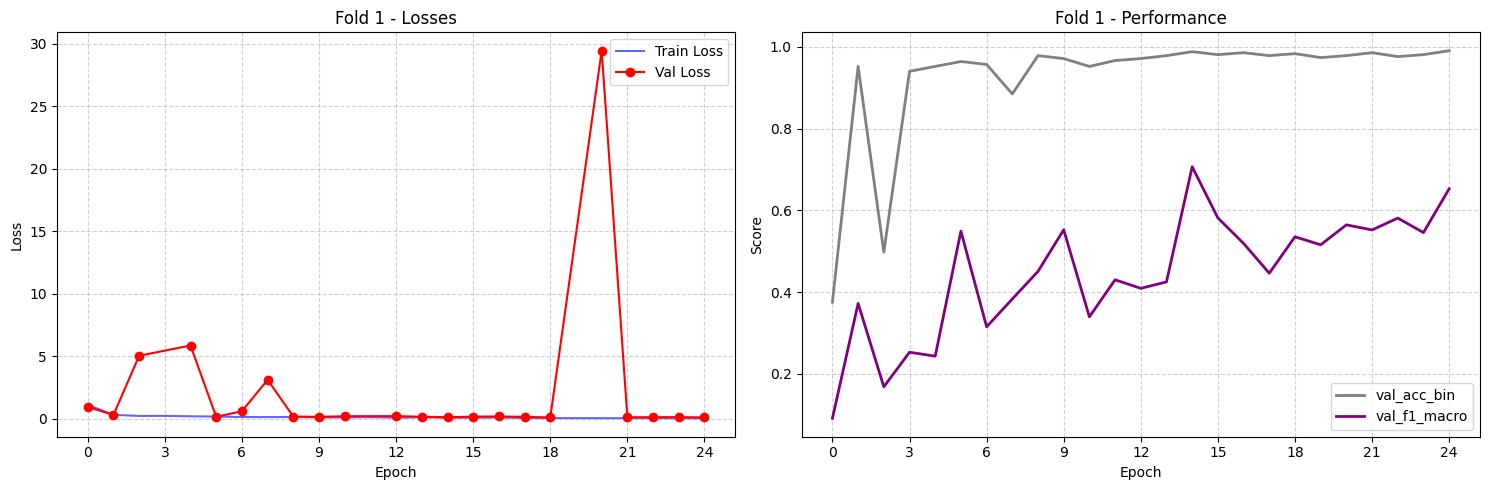


[23:29:27] --- Treinando Fold 2/5 ---


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_baseline_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


[23:34:11] 🧪 Avaliando melhor modelo do Fold 2...
[23:34:13] ✅ Fold 2 finalizado. Melhor Época: 23
[23:34:13] 🏆 Val F1 Macro (Best): 0.6929


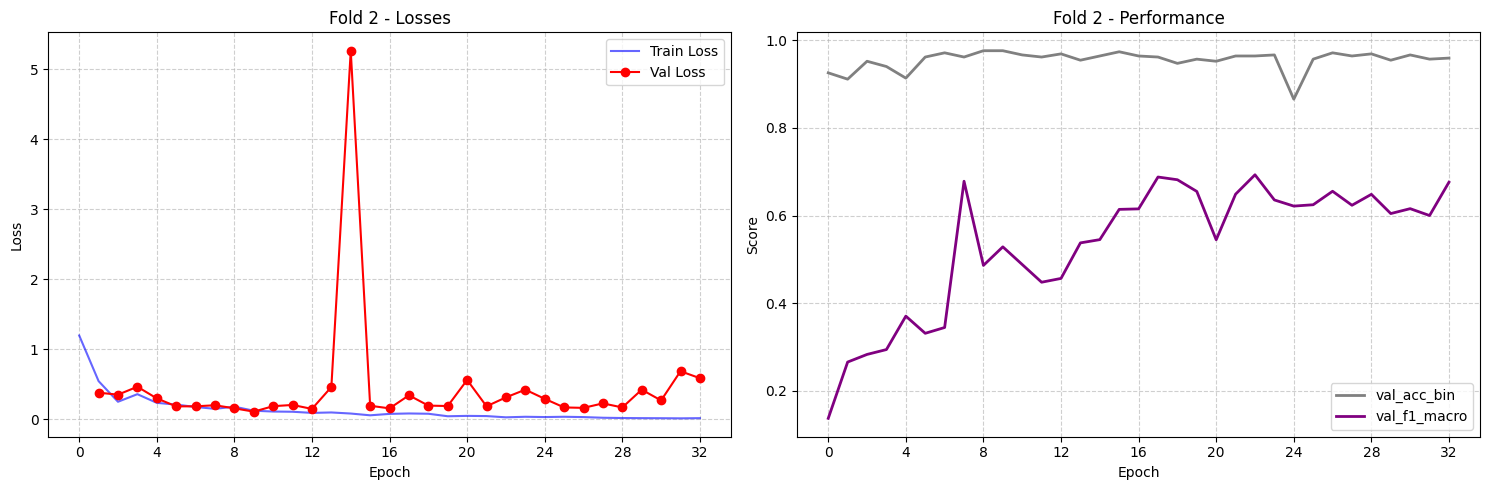


[23:34:14] --- Treinando Fold 3/5 ---


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_baseline_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


[23:37:26] 🧪 Avaliando melhor modelo do Fold 3...


[23:37:28] ✅ Fold 3 finalizado. Melhor Época: 12
[23:37:28] 🏆 Val F1 Macro (Best): 0.7442


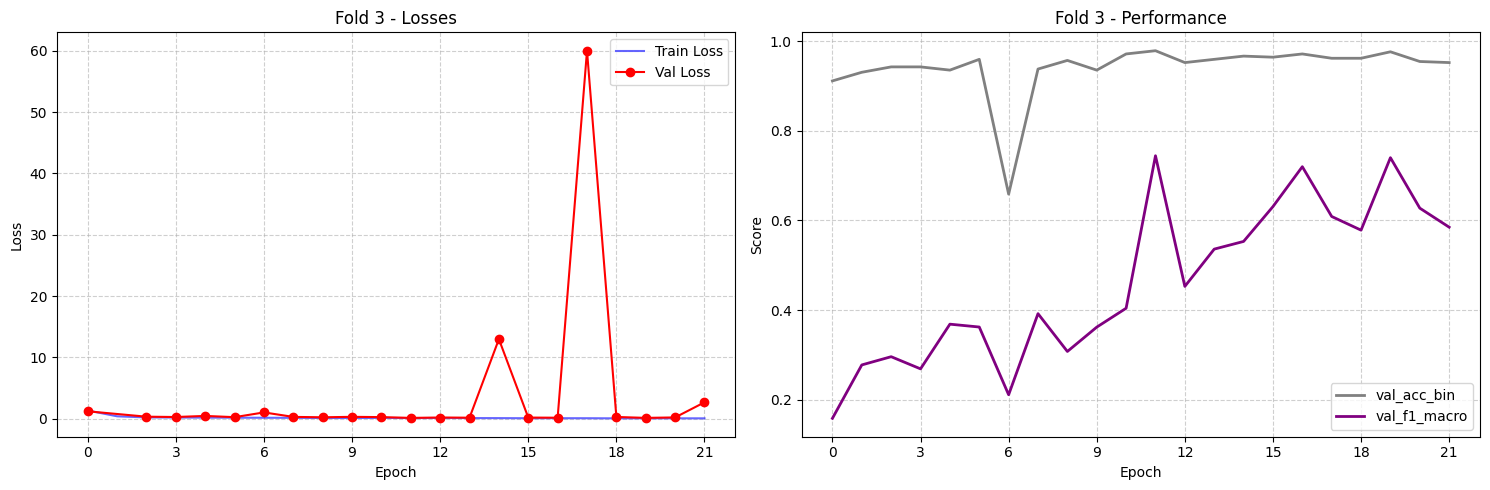


[23:37:29] --- Treinando Fold 4/5 ---


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_baseline_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


[23:42:42] 🧪 Avaliando melhor modelo do Fold 4...
[23:42:44] ✅ Fold 4 finalizado. Melhor Época: 24
[23:42:44] 🏆 Val F1 Macro (Best): 0.7429


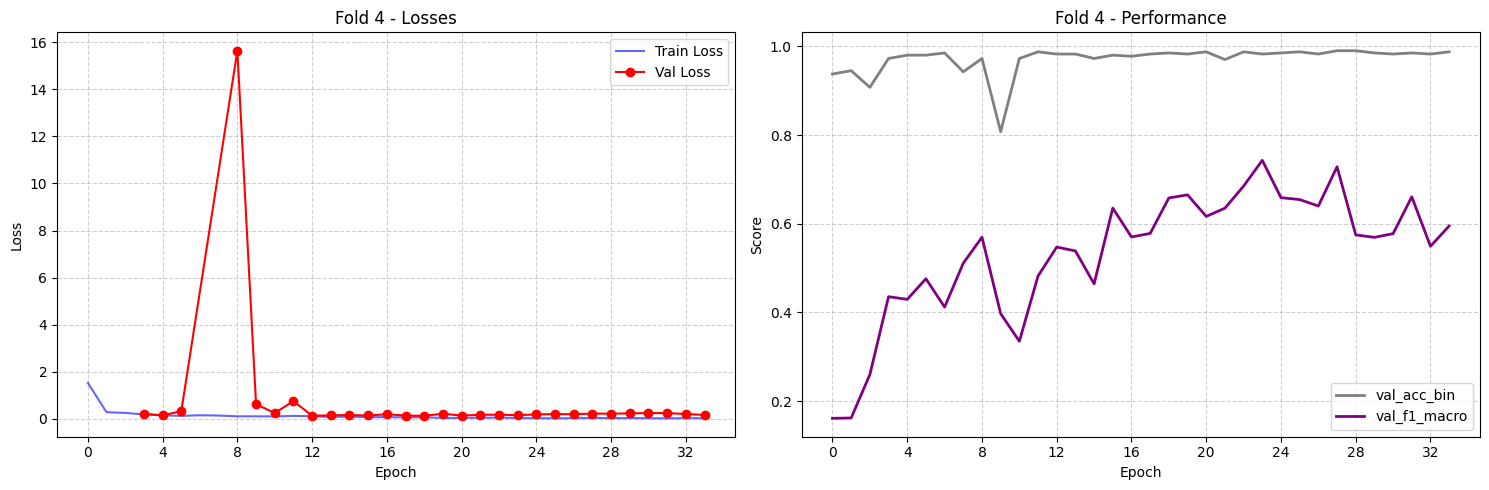


[23:42:45] --- Treinando Fold 5/5 ---


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_baseline_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


[23:48:09] 🧪 Avaliando melhor modelo do Fold 5...
[23:48:12] ✅ Fold 5 finalizado. Melhor Época: 27
[23:48:12] 🏆 Val F1 Macro (Best): 0.5738


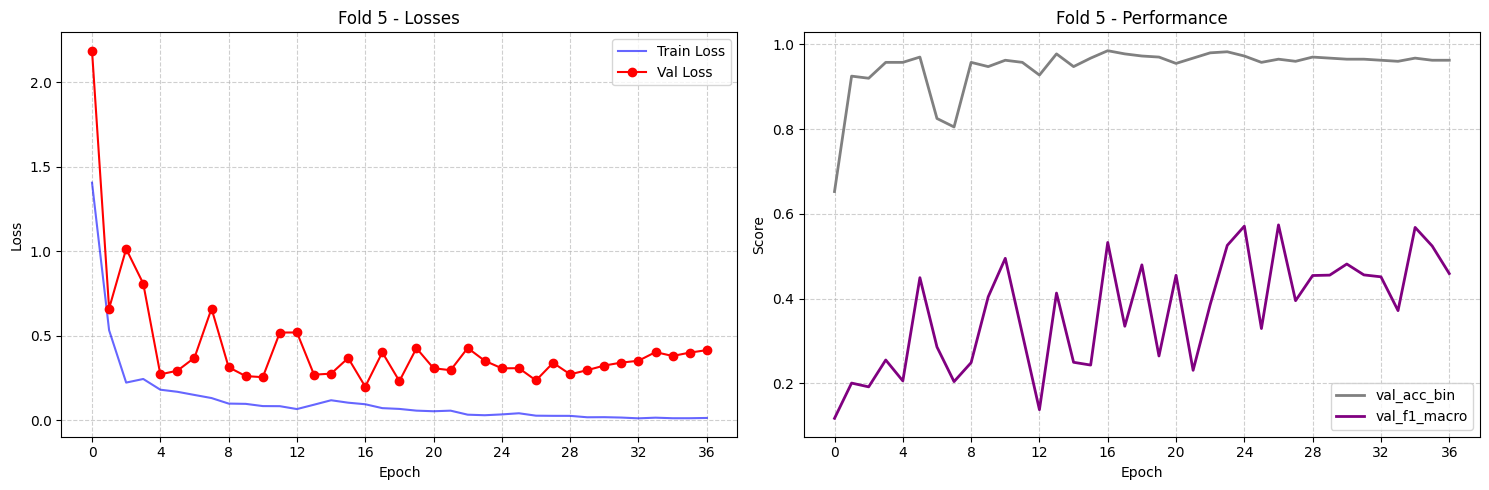


📊 RELATÓRIO DA VALIDAÇÃO CRUZADA (5 Folds)
🔸 F1 Macro          : 0.6921 ± 0.0625
🔸 F1 Weighted       : 0.9643 ± 0.0120
🔸 Precision Macro   : 0.7940 ± 0.0663
🔸 Recall Macro      : 0.6683 ± 0.0811
🔸 Binary Accuracy   : 0.9741 ± 0.0102


[23:48:12] 🌟 Folds concluídos! Mediana de Épocas: 23
[23:48:12] 🌟 Iniciando Treino do Modelo Final (Train + Val combinados)...


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_baseline_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead

[23:52:03] 📊 Gerando gráfico do Modelo Final...


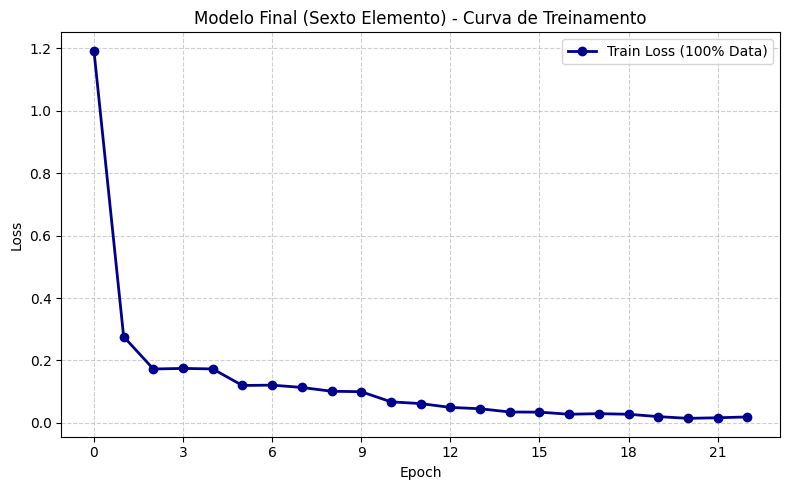


[23:52:04] 🚨 Carregando dados de Teste (Holdout)...

[23:52:04] 🔮 Extraindo predições do Holdout Test...

📊 RELATÓRIO DE CLASSIFICAÇÃO DETALHADO (HOLDOUT EXATO)
                 precision    recall  f1-score   support

           good       0.98      0.99      0.99       498
      brokenEnd       0.33      0.17      0.22         6
           hole       0.50      0.50      0.50         4
nettingMultiple       0.50      0.86      0.63         7
       thickBar       0.60      0.75      0.67         4
        thinBar       1.00      0.14      0.25         7
          knots       1.00      0.50      0.67         2

       accuracy                           0.96       528
      macro avg       0.70      0.56      0.56       528
   weighted avg       0.96      0.96      0.96       528



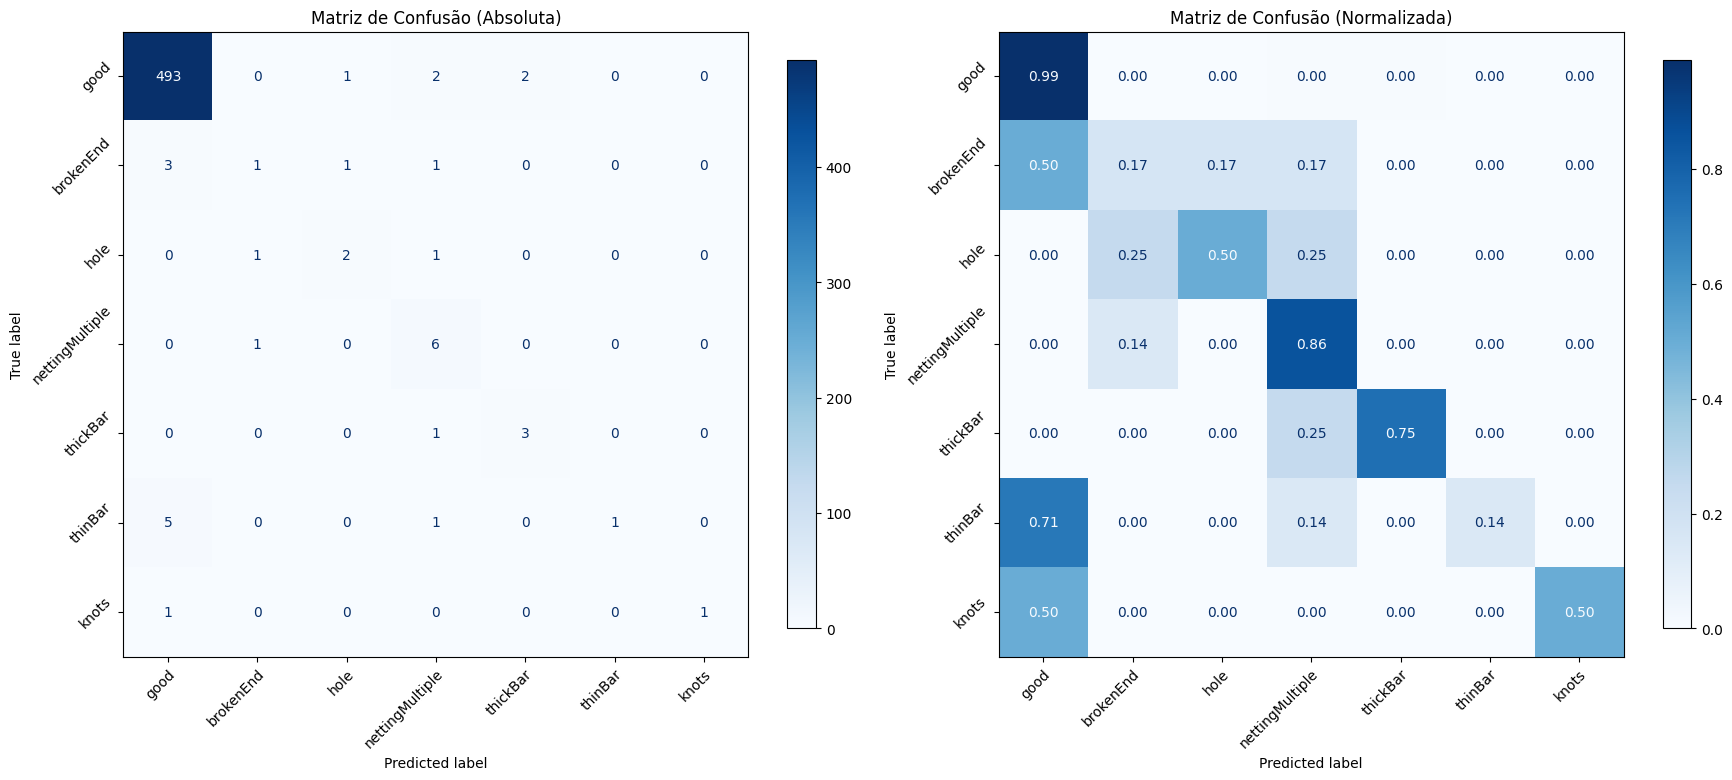


[23:52:06] 🎲 Iniciando Bootstrapping (1000 iterações)...

🏆 RESULTADOS FINAIS NO HOLDOUT (BOOTSTRAPPING - 95% CI) 🏆
🔹 F1 Macro          : 0.5275 (95% CI: [0.3597, 0.6838])  | Exato: 0.5604
🔹 F1 Weighted       : 0.9556 (95% CI: [0.9351, 0.9736])  | Exato: 0.9556
🔹 Precision Macro   : 0.6028 (95% CI: [0.3603, 0.8108])  | Exato: 0.7022
🔹 Recall Macro      : 0.5573 (95% CI: [0.3941, 0.7135])  | Exato: 0.5581
🔹 Binary Accuracy   : 0.9737 (95% CI: [0.9602, 0.9867])  | Exato: 0.9735


[2026-05-14 23:52:12] 🎉 EXPERIMENTO CONCLUÍDO! Tudo salvo em: ./experiments/HKU_64_baseline_mobilenetv3_large_150d.ra4_e3600_r256_in1k


In [8]:
DATASET = "HKU"
# DATASET = "TILDA"

# PSIZE = 32
PSIZE = 64
# PSIZE = 128

# MODEL_NAME = "fastvit_t8.apple_in1k"
MODEL_NAME = "mobilenetv3_large_150d.ra4_e3600_r256_in1k"
# MODEL_NAME = "resnet50.fb_swsl_ig1b_ft_in1k"
# MODEL_NAME = "mobilenetv4_hybrid_medium.e200_r256_in12k_ft_in1k"

EXPERIMENT_TYPE = "baseline"
# EXPERIMENT_TYPE = "undersampling"
# EXPERIMENT_TYPE = "focal_loss"
# EXPERIMENT_TYPE = "wce"

UNDER_RATIO = None
# UNDER_RATIO = 1
# UNDER_RATIO = 5

set_seed(SEED)
run_lightning_experiment(dataset_name=DATASET, 
                         resolution=PSIZE, 
                         model_name=MODEL_NAME, 
                         experiment_type=EXPERIMENT_TYPE, 
                         undersample_ratio=UNDER_RATIO, 
                         num_epochs=N_EPOCHS, 
                         batch_size=BATCH_SIZE)

Seed set to 42


[23:52:13] Seed set as 42

[2026-05-14 23:52:13] 🚀 INICIANDO: HKU | 64px | mobilenetv3_large_150d.ra4_e3600_r256_in1k | UNDERSAMPLING

[23:52:13] --- Treinando Fold 1/5 ---


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_undersampling_ratio1_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ MobileNetV3        │ 13.4 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ multi_f1  │ MulticlassF1Score  │      0 │ train │     0 │
│ 3 │ multi_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 4 │ bin_f1    │ BinaryF1Score      │      0 │ train │     0 │
│ 5 │ bin_acc   │ BinaryAccuracy     │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 13.4 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 13.4 M                                                                                               
Total estimated model params size (MB): 53                                                                         
Modules in train mode: 412                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:317: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/module.py:1333: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate


[23:54:35] 🧪 Avaliando melhor modelo do Fold 1...
[23:54:37] ✅ Fold 1 finalizado. Melhor Época: 36
[23:54:37] 🏆 Val F1 Macro (Best): 0.6611


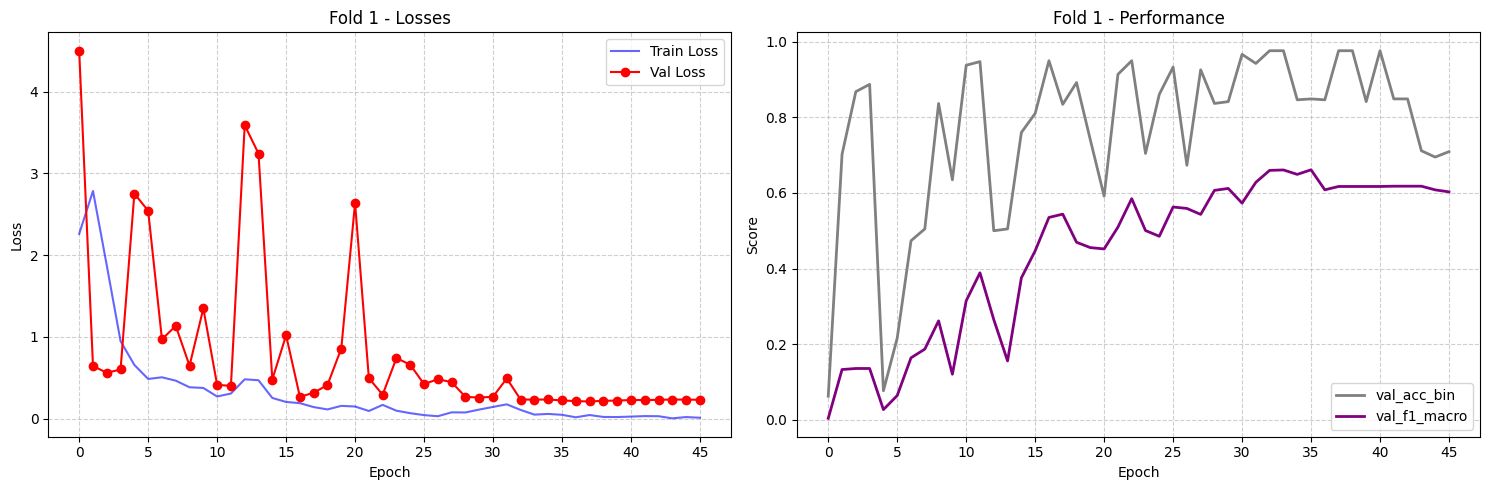


[23:54:38] --- Treinando Fold 2/5 ---


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_undersampling_ratio1_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:317: The number of training batches (4) is smaller than the logging interval Trainer(log

[23:56:55] 🧪 Avaliando melhor modelo do Fold 2...
[23:56:57] ✅ Fold 2 finalizado. Melhor Época: 35
[23:56:57] 🏆 Val F1 Macro (Best): 0.7280


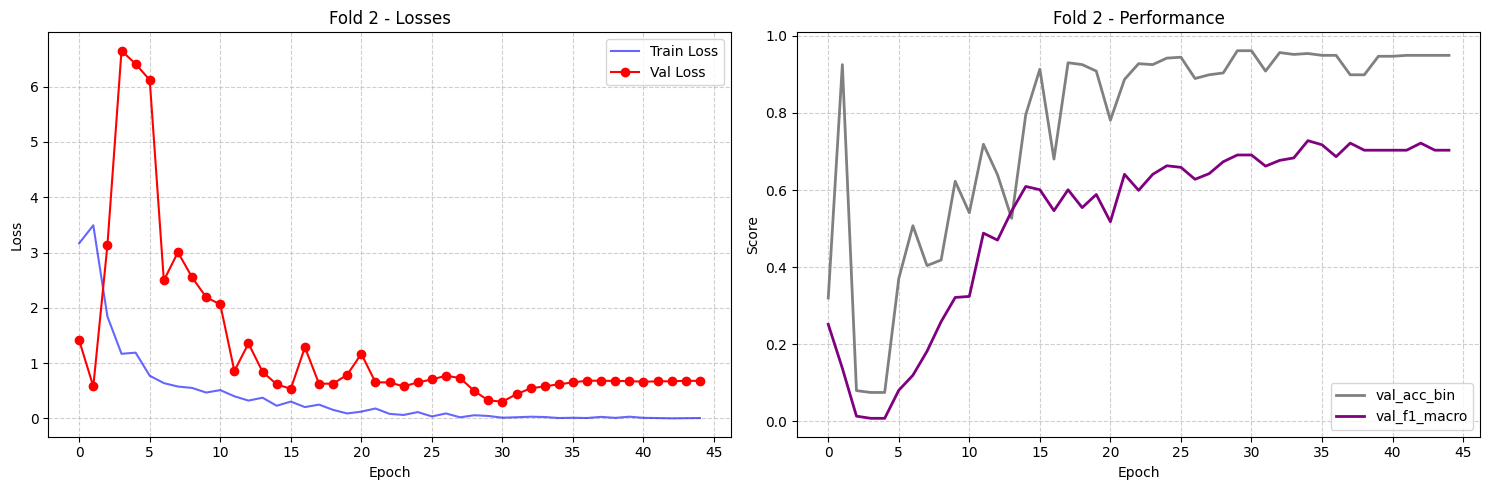


[23:56:58] --- Treinando Fold 3/5 ---


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_undersampling_ratio1_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:317: The number of training batches (4) is smaller than the logging interval Trainer(log

[23:59:08] 🧪 Avaliando melhor modelo do Fold 3...
[23:59:10] ✅ Fold 3 finalizado. Melhor Época: 34
[23:59:10] 🏆 Val F1 Macro (Best): 0.6074


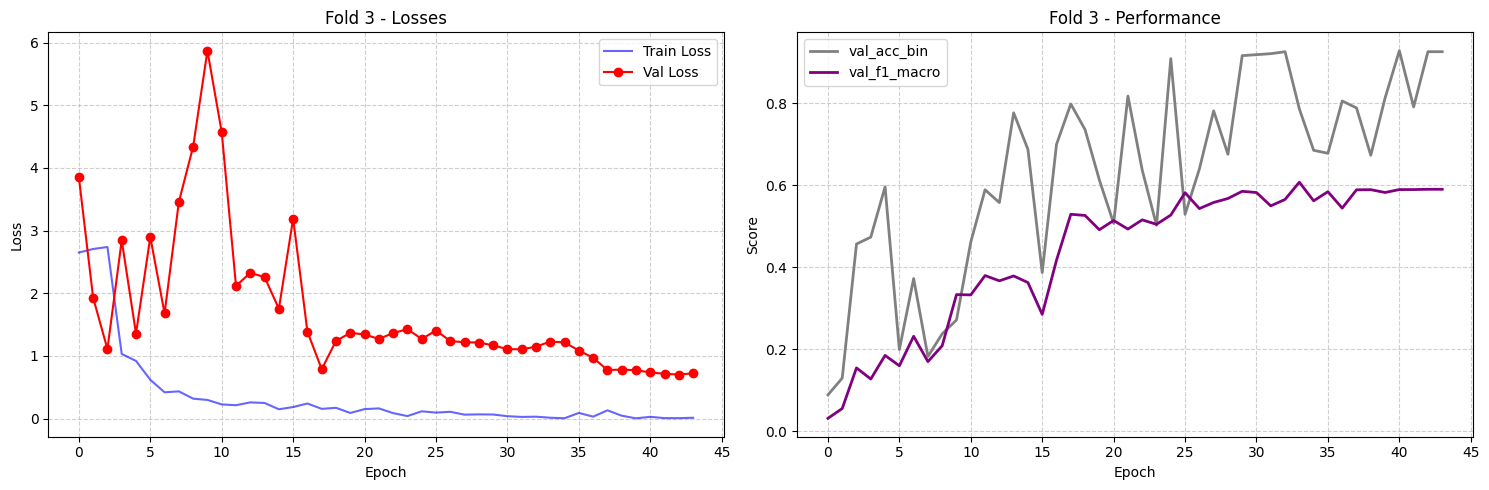


[23:59:11] --- Treinando Fold 4/5 ---


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_undersampling_ratio1_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:317: The number of training batches (5) is smaller than the logging interval Trainer(log

[00:00:37] 🧪 Avaliando melhor modelo do Fold 4...
[00:00:39] ✅ Fold 4 finalizado. Melhor Época: 17
[00:00:39] 🏆 Val F1 Macro (Best): 0.4412


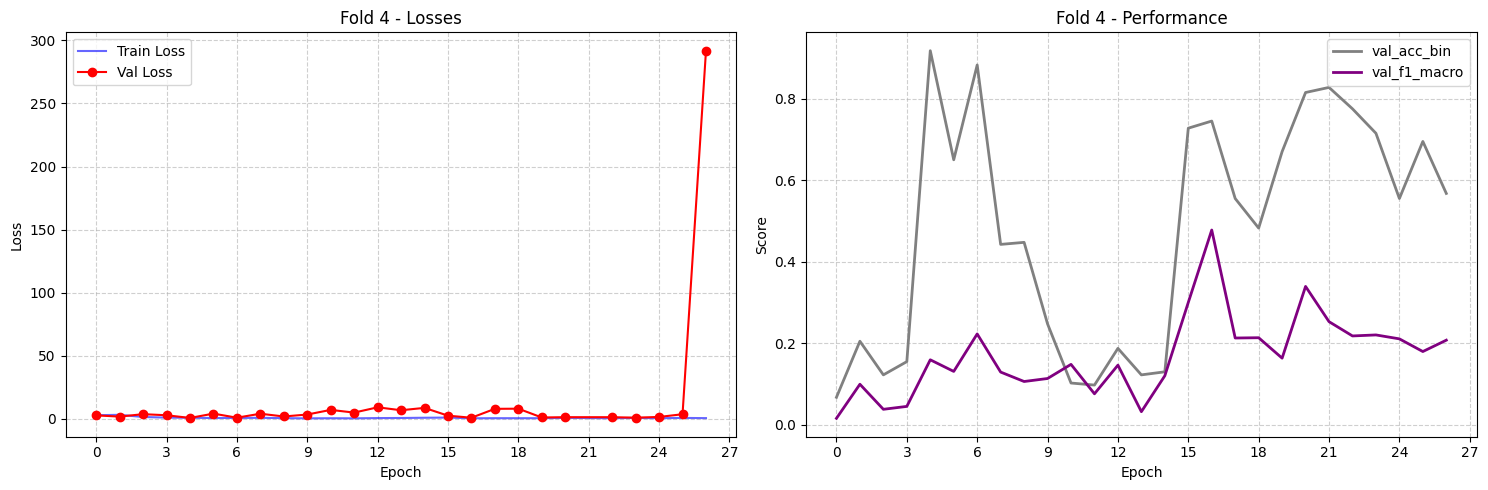


[00:00:40] --- Treinando Fold 5/5 ---


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_undersampling_ratio1_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:317: The number of training batches (4) is smaller than the logging interval Trainer(log

[00:02:18] 🧪 Avaliando melhor modelo do Fold 5...
[00:02:20] ✅ Fold 5 finalizado. Melhor Época: 25
[00:02:20] 🏆 Val F1 Macro (Best): 0.5190


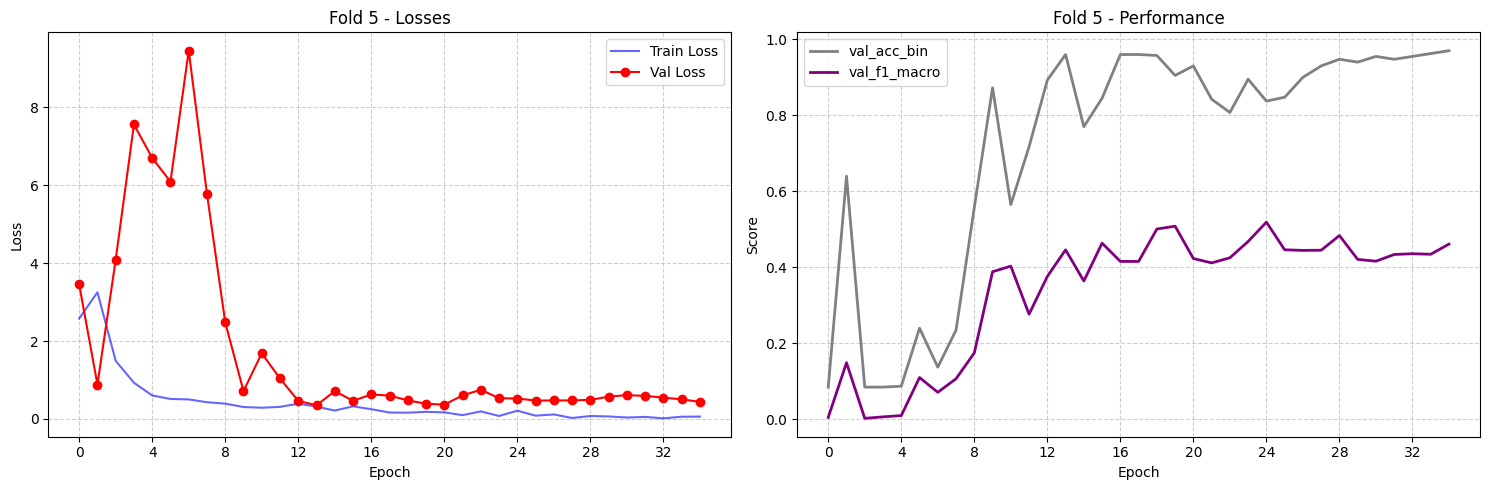


📊 RELATÓRIO DA VALIDAÇÃO CRUZADA (5 Folds)
🔸 F1 Macro          : 0.5914 ± 0.1016
🔸 F1 Weighted       : 0.9190 ± 0.0549
🔸 Precision Macro   : 0.5823 ± 0.0864
🔸 Recall Macro      : 0.6899 ± 0.1611
🔸 Binary Accuracy   : 0.9087 ± 0.0823


[00:02:21] 🌟 Folds concluídos! Mediana de Épocas: 34
[00:02:21] 🌟 Iniciando Treino do Modelo Final (Train + Val combinados)...


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_undersampling_ratio1_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_lea

[00:04:00] 📊 Gerando gráfico do Modelo Final...


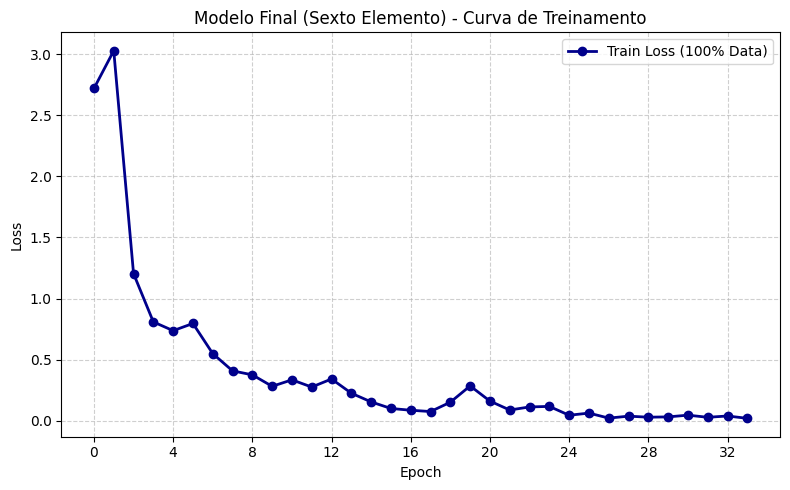


[00:04:01] 🚨 Carregando dados de Teste (Holdout)...

[00:04:01] 🔮 Extraindo predições do Holdout Test...

📊 RELATÓRIO DE CLASSIFICAÇÃO DETALHADO (HOLDOUT EXATO)
                 precision    recall  f1-score   support

           good       1.00      0.99      1.00       498
      brokenEnd       0.67      0.67      0.67         6
           hole       0.60      0.75      0.67         4
nettingMultiple       0.60      0.86      0.71         7
       thickBar       0.75      0.75      0.75         4
        thinBar       0.80      0.57      0.67         7
          knots       1.00      1.00      1.00         2

       accuracy                           0.98       528
      macro avg       0.77      0.80      0.78       528
   weighted avg       0.98      0.98      0.98       528



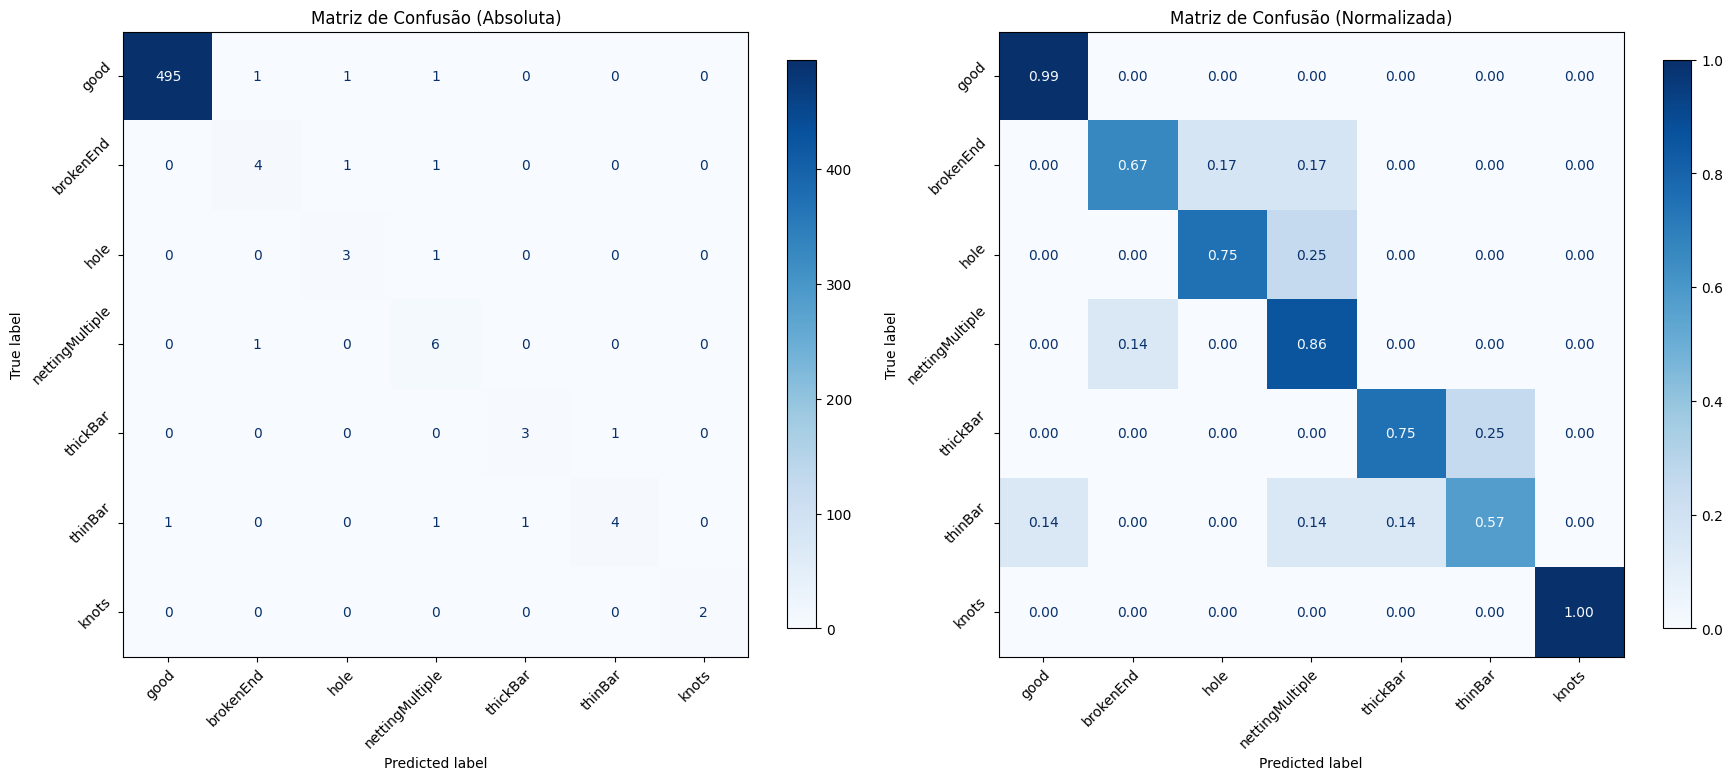


[00:04:03] 🎲 Iniciando Bootstrapping (1000 iterações)...

🏆 RESULTADOS FINAIS NO HOLDOUT (BOOTSTRAPPING - 95% CI) 🏆
🔹 F1 Macro          : 0.7553 (95% CI: [0.6097, 0.8857])  | Exato: 0.7788
🔹 F1 Weighted       : 0.9798 (95% CI: [0.9660, 0.9907])  | Exato: 0.9797
🔹 Precision Macro   : 0.7664 (95% CI: [0.6122, 0.9045])  | Exato: 0.7735
🔹 Recall Macro      : 0.7904 (95% CI: [0.6317, 0.9198])  | Exato: 0.7985
🔹 Binary Accuracy   : 0.9923 (95% CI: [0.9848, 0.9981])  | Exato: 0.9924


[2026-05-15 00:04:09] 🎉 EXPERIMENTO CONCLUÍDO! Tudo salvo em: ./experiments/HKU_64_undersampling_ratio1_mobilenetv3_large_150d.ra4_e3600_r256_in1k


In [9]:
DATASET = "HKU"
# DATASET = "TILDA"

# PSIZE = 32
PSIZE = 64
# PSIZE = 128

# MODEL_NAME = "fastvit_t8.apple_in1k"
MODEL_NAME = "mobilenetv3_large_150d.ra4_e3600_r256_in1k"
# MODEL_NAME = "resnet50.fb_swsl_ig1b_ft_in1k"

# EXPERIMENT_TYPE = "baseline"
EXPERIMENT_TYPE = "undersampling"
# EXPERIMENT_TYPE = "focal_loss"
# EXPERIMENT_TYPE = "wce"

# UNDER_RATIO = None
UNDER_RATIO = 1
# UNDER_RATIO = 5

set_seed(SEED)
run_lightning_experiment(dataset_name=DATASET, 
                         resolution=PSIZE, 
                         model_name=MODEL_NAME, 
                         experiment_type=EXPERIMENT_TYPE, 
                         undersample_ratio=UNDER_RATIO, 
                         num_epochs=N_EPOCHS, 
                         batch_size=BATCH_SIZE)

Seed set to 42


[00:04:09] Seed set as 42

[2026-05-15 00:04:09] 🚀 INICIANDO: HKU | 64px | mobilenetv3_large_150d.ra4_e3600_r256_in1k | UNDERSAMPLING

[00:04:10] --- Treinando Fold 1/5 ---


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_undersampling_ratio5_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ MobileNetV3        │ 13.4 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ multi_f1  │ MulticlassF1Score  │      0 │ train │     0 │
│ 3 │ multi_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 4 │ bin_f1    │ BinaryF1Score      │      0 │ train │     0 │
│ 5 │ bin_acc   │ BinaryAccuracy     │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 13.4 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 13.4 M                                                                                               
Total estimated model params size (MB): 53                                                                         
Modules in train mode: 412                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


[00:06:14] 🧪 Avaliando melhor modelo do Fold 1...
[00:06:17] ✅ Fold 1 finalizado. Melhor Época: 12
[00:06:17] 🏆 Val F1 Macro (Best): 0.6655


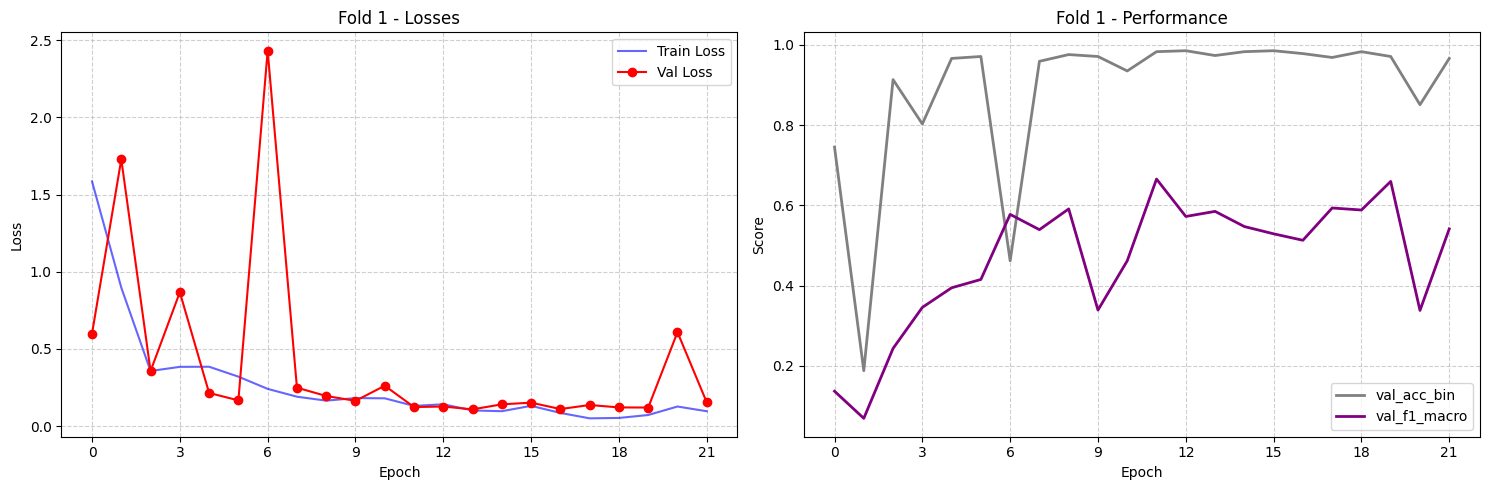


[00:06:17] --- Treinando Fold 2/5 ---


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_undersampling_ratio5_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


[00:09:20] 🧪 Avaliando melhor modelo do Fold 2...
[00:09:22] ✅ Fold 2 finalizado. Melhor Época: 24
[00:09:22] 🏆 Val F1 Macro (Best): 0.7160


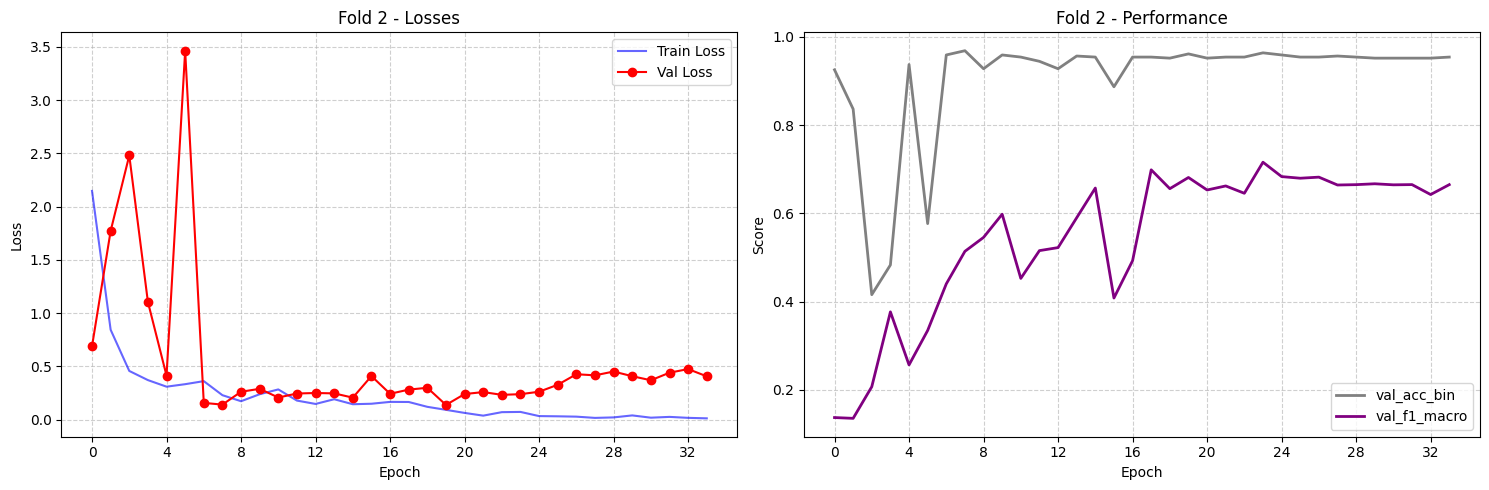


[00:09:23] --- Treinando Fold 3/5 ---


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_undersampling_ratio5_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


[00:12:12] 🧪 Avaliando melhor modelo do Fold 3...
[00:12:14] ✅ Fold 3 finalizado. Melhor Época: 24
[00:12:14] 🏆 Val F1 Macro (Best): 0.7486


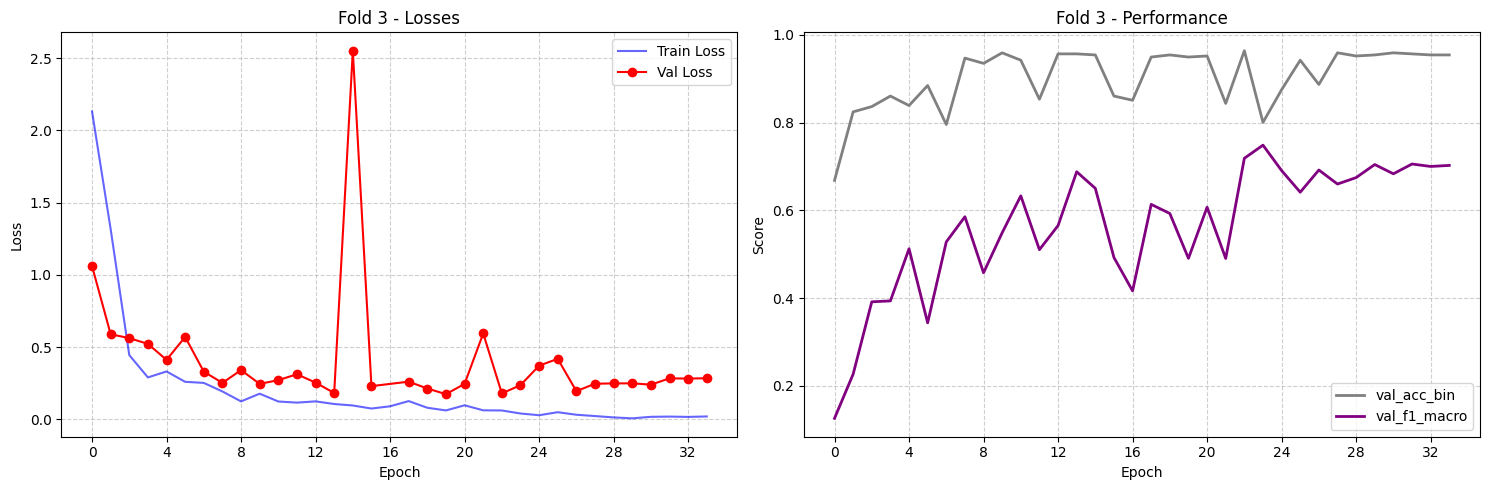


[00:12:14] --- Treinando Fold 4/5 ---


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_undersampling_ratio5_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


[00:15:31] 🧪 Avaliando melhor modelo do Fold 4...
[00:15:33] ✅ Fold 4 finalizado. Melhor Época: 26
[00:15:33] 🏆 Val F1 Macro (Best): 0.6598


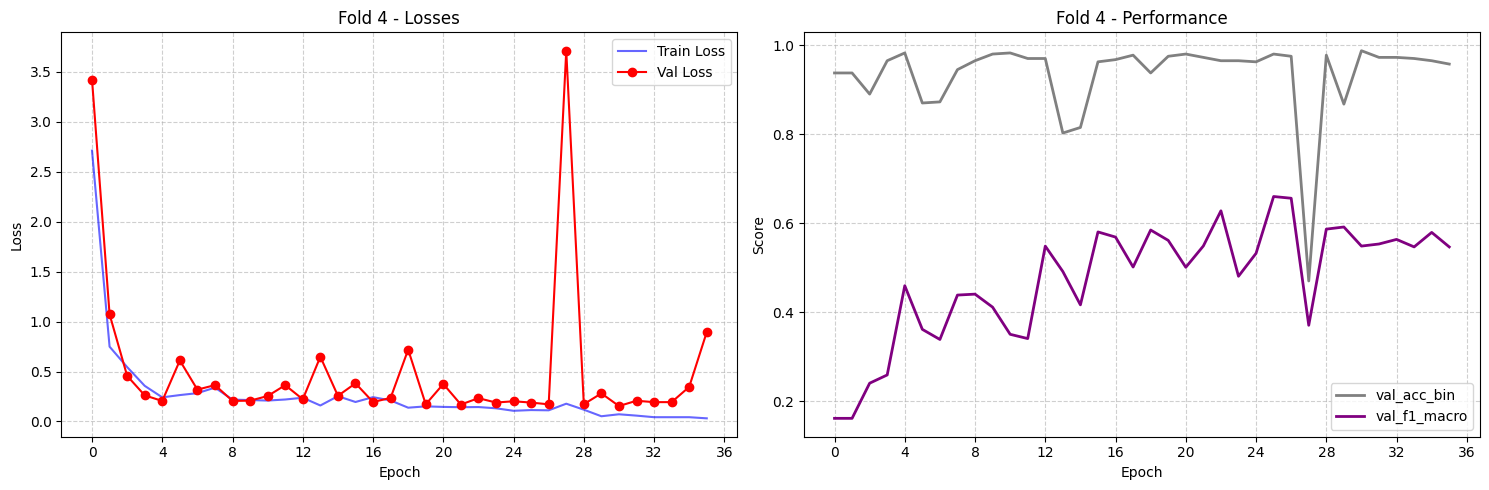


[00:15:34] --- Treinando Fold 5/5 ---


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_undersampling_ratio5_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


[00:18:43] 🧪 Avaliando melhor modelo do Fold 5...
[00:18:45] ✅ Fold 5 finalizado. Melhor Época: 26
[00:18:45] 🏆 Val F1 Macro (Best): 0.7134


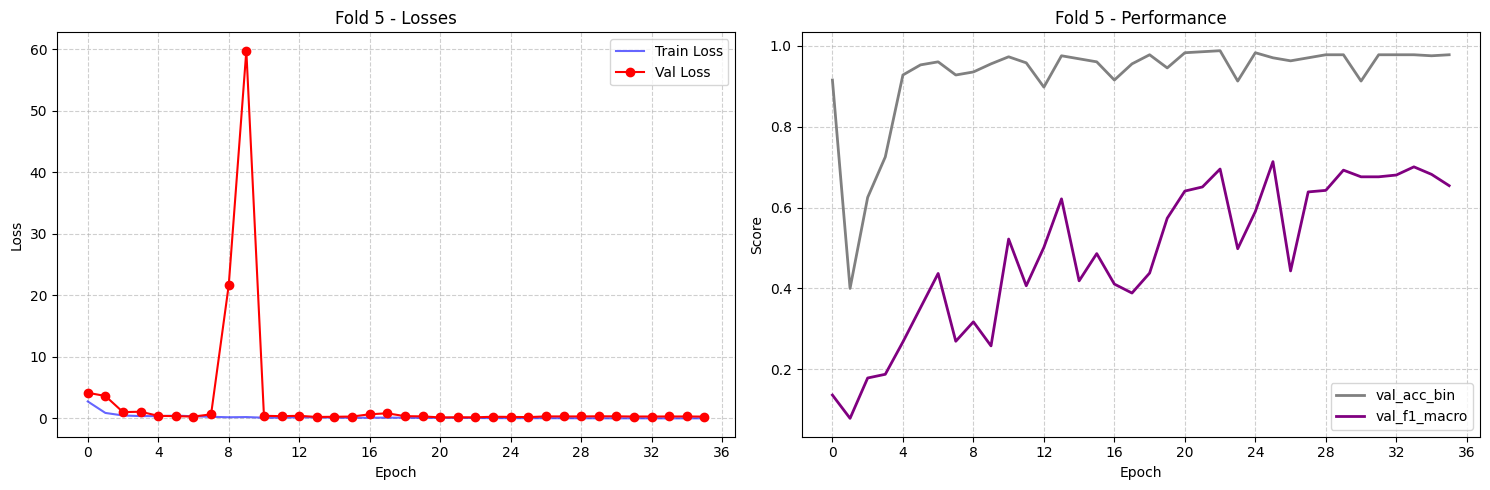


📊 RELATÓRIO DA VALIDAÇÃO CRUZADA (5 Folds)
🔸 F1 Macro          : 0.7007 ± 0.0335
🔸 F1 Weighted       : 0.9639 ± 0.0056
🔸 Precision Macro   : 0.7324 ± 0.0525
🔸 Recall Macro      : 0.7401 ± 0.0648
🔸 Binary Accuracy   : 0.9717 ± 0.0086


[00:18:46] 🌟 Folds concluídos! Mediana de Épocas: 24
[00:18:46] 🌟 Iniciando Treino do Modelo Final (Train + Val combinados)...


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_undersampling_ratio5_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_lea

[00:21:06] 📊 Gerando gráfico do Modelo Final...


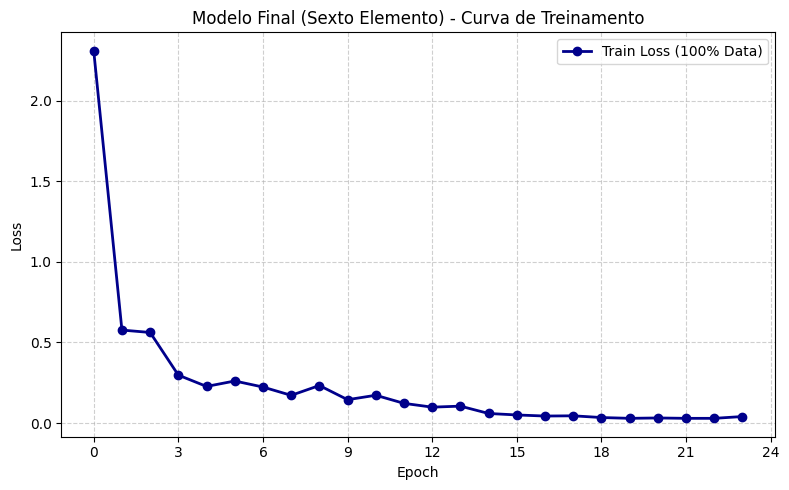


[00:21:06] 🚨 Carregando dados de Teste (Holdout)...

[00:21:06] 🔮 Extraindo predições do Holdout Test...

📊 RELATÓRIO DE CLASSIFICAÇÃO DETALHADO (HOLDOUT EXATO)
                 precision    recall  f1-score   support

           good       0.99      0.99      0.99       498
      brokenEnd       1.00      0.17      0.29         6
           hole       0.43      0.75      0.55         4
nettingMultiple       0.43      0.86      0.57         7
       thickBar       0.50      0.50      0.50         4
        thinBar       1.00      0.14      0.25         7
          knots       1.00      0.50      0.67         2

       accuracy                           0.96       528
      macro avg       0.76      0.56      0.54       528
   weighted avg       0.97      0.96      0.96       528



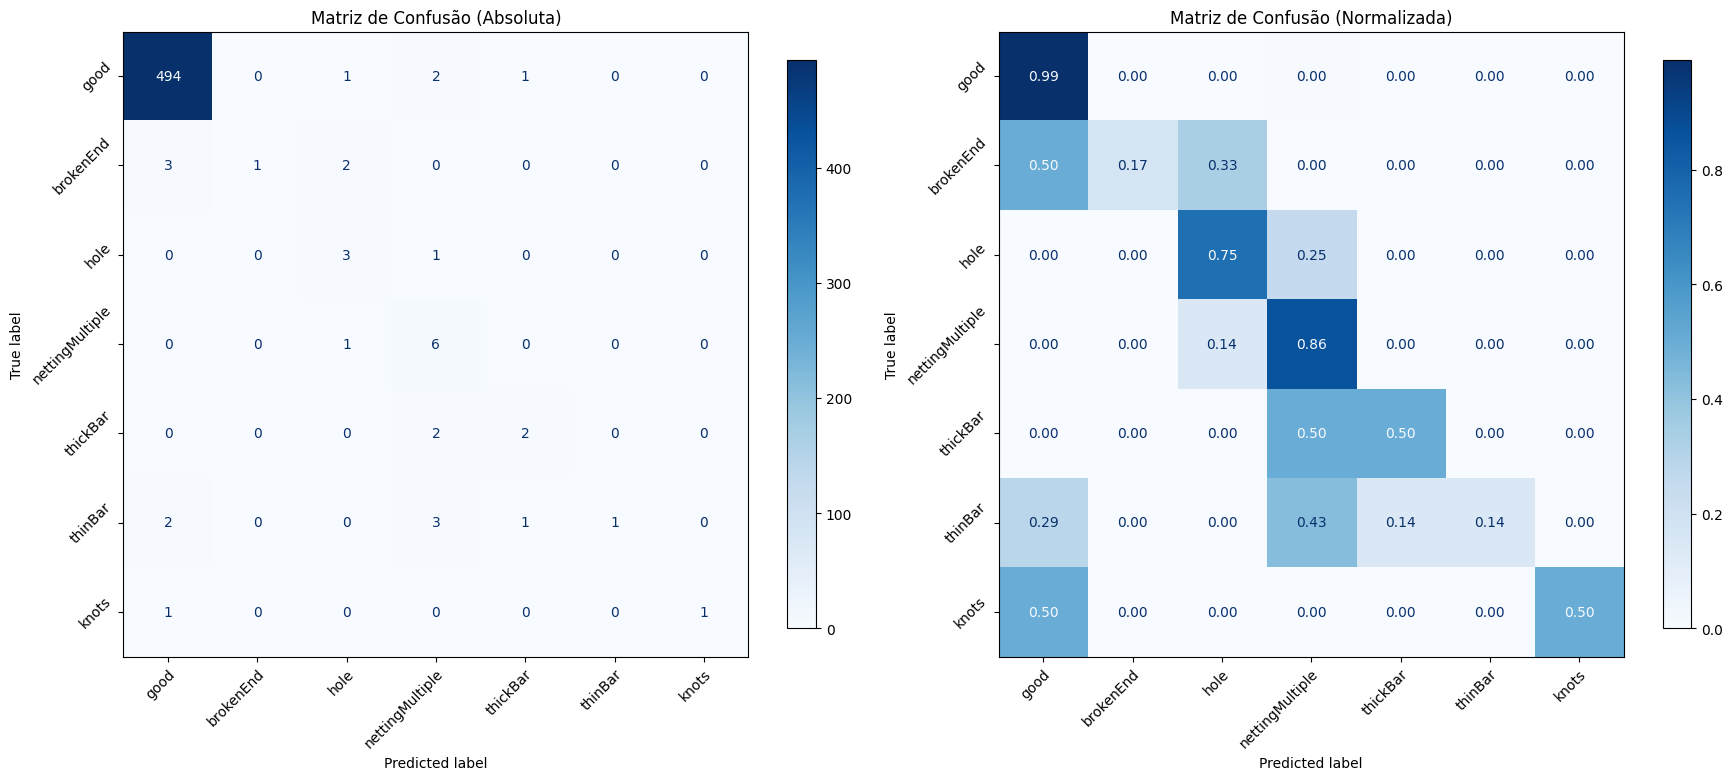


[00:21:08] 🎲 Iniciando Bootstrapping (1000 iterações)...

🏆 RESULTADOS FINAIS NO HOLDOUT (BOOTSTRAPPING - 95% CI) 🏆
🔹 F1 Macro          : 0.5110 (95% CI: [0.3360, 0.6755])  | Exato: 0.5442
🔹 F1 Weighted       : 0.9584 (95% CI: [0.9387, 0.9754])  | Exato: 0.9583
🔹 Precision Macro   : 0.6181 (95% CI: [0.3355, 0.8364])  | Exato: 0.7636
🔹 Recall Macro      : 0.5576 (95% CI: [0.3846, 0.7123])  | Exato: 0.5584
🔹 Binary Accuracy   : 0.9812 (95% CI: [0.9678, 0.9924])  | Exato: 0.9811


[2026-05-15 00:21:15] 🎉 EXPERIMENTO CONCLUÍDO! Tudo salvo em: ./experiments/HKU_64_undersampling_ratio5_mobilenetv3_large_150d.ra4_e3600_r256_in1k


In [10]:
DATASET = "HKU"
# DATASET = "TILDA"

# PSIZE = 32
PSIZE = 64
# PSIZE = 128

# MODEL_NAME = "fastvit_t8.apple_in1k"
MODEL_NAME = "mobilenetv3_large_150d.ra4_e3600_r256_in1k"
# MODEL_NAME = "resnet50.fb_swsl_ig1b_ft_in1k"

# EXPERIMENT_TYPE = "baseline"
EXPERIMENT_TYPE = "undersampling"
# EXPERIMENT_TYPE = "focal_loss"
# EXPERIMENT_TYPE = "wce"

# UNDER_RATIO = None
# UNDER_RATIO = 1
UNDER_RATIO = 5

set_seed(SEED)
run_lightning_experiment(dataset_name=DATASET, 
                         resolution=PSIZE, 
                         model_name=MODEL_NAME, 
                         experiment_type=EXPERIMENT_TYPE, 
                         undersample_ratio=UNDER_RATIO, 
                         num_epochs=N_EPOCHS, 
                         batch_size=BATCH_SIZE)

Seed set to 42


[00:21:15] Seed set as 42

[2026-05-15 00:21:15] 🚀 INICIANDO: HKU | 64px | mobilenetv3_large_150d.ra4_e3600_r256_in1k | FOCAL_LOSS

[00:21:15] --- Treinando Fold 1/5 ---


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_focal_loss_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ MobileNetV3         │ 13.4 M │ train │     0 │
│ 1 │ criterion │ MulticlassFocalLoss │      0 │ train │     0 │
│ 2 │ multi_f1  │ MulticlassF1Score   │      0 │ train │     0 │
│ 3 │ multi_acc │ MulticlassAccuracy  │      0 │ train │     0 │
│ 4 │ bin_f1    │ BinaryF1Score       │      0 │ train │     0 │
│ 5 │ bin_acc   │ BinaryAccuracy      │      0 │ train │     0 │
└───┴───────────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 13.4 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 13.4 M                                                                                               
Total estimated model params size (MB): 53                                                                         
Modules in train mode: 412                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


[00:23:57] 🧪 Avaliando melhor modelo do Fold 1...
[00:24:00] ✅ Fold 1 finalizado. Melhor Época: 8
[00:24:00] 🏆 Val F1 Macro (Best): 0.3976


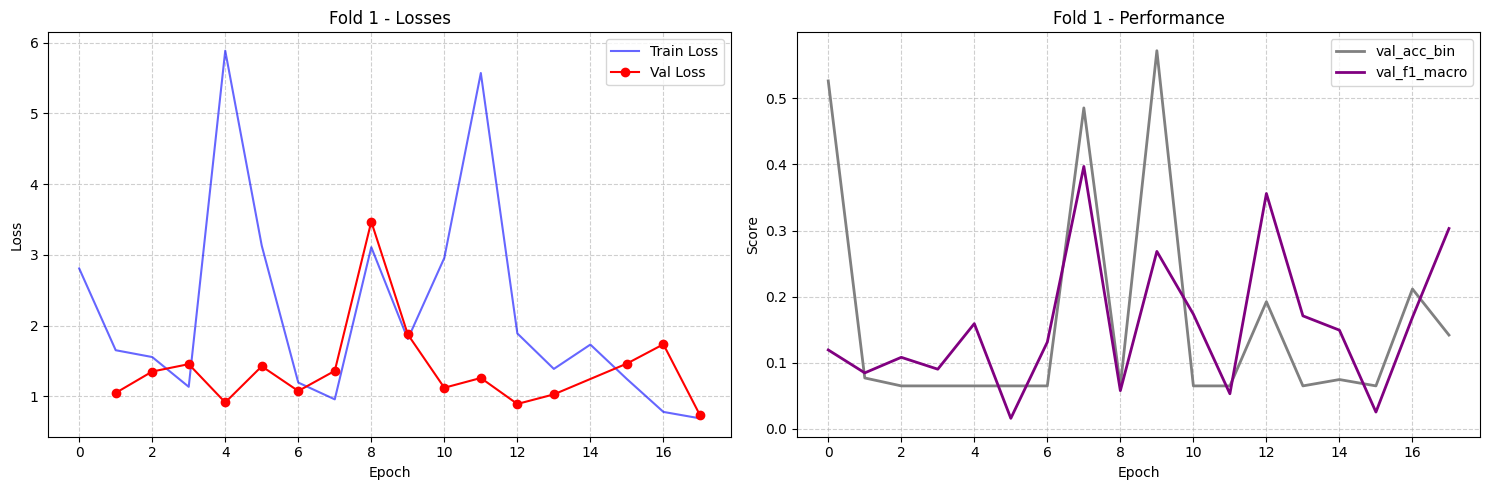


[00:24:01] --- Treinando Fold 2/5 ---


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_focal_loss_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


[00:26:09] 🧪 Avaliando melhor modelo do Fold 2...
[00:26:11] ✅ Fold 2 finalizado. Melhor Época: 4
[00:26:11] 🏆 Val F1 Macro (Best): 0.5378


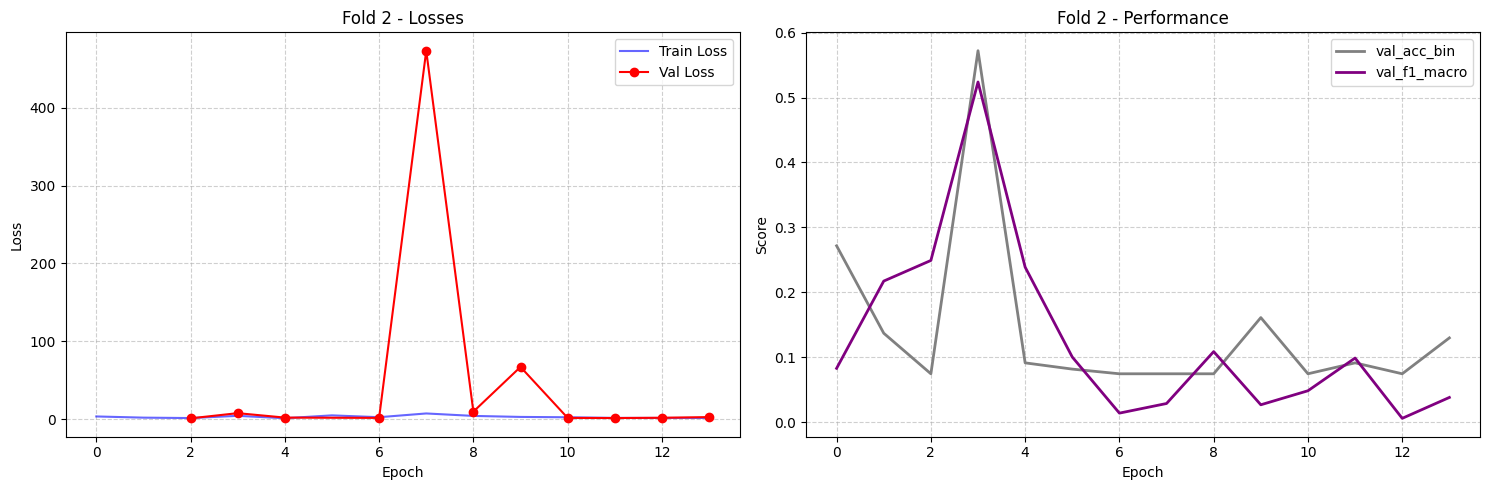


[00:26:12] --- Treinando Fold 3/5 ---


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_focal_loss_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


[00:32:21] 🧪 Avaliando melhor modelo do Fold 3...
[00:32:23] ✅ Fold 3 finalizado. Melhor Época: 31
[00:32:23] 🏆 Val F1 Macro (Best): 0.4358


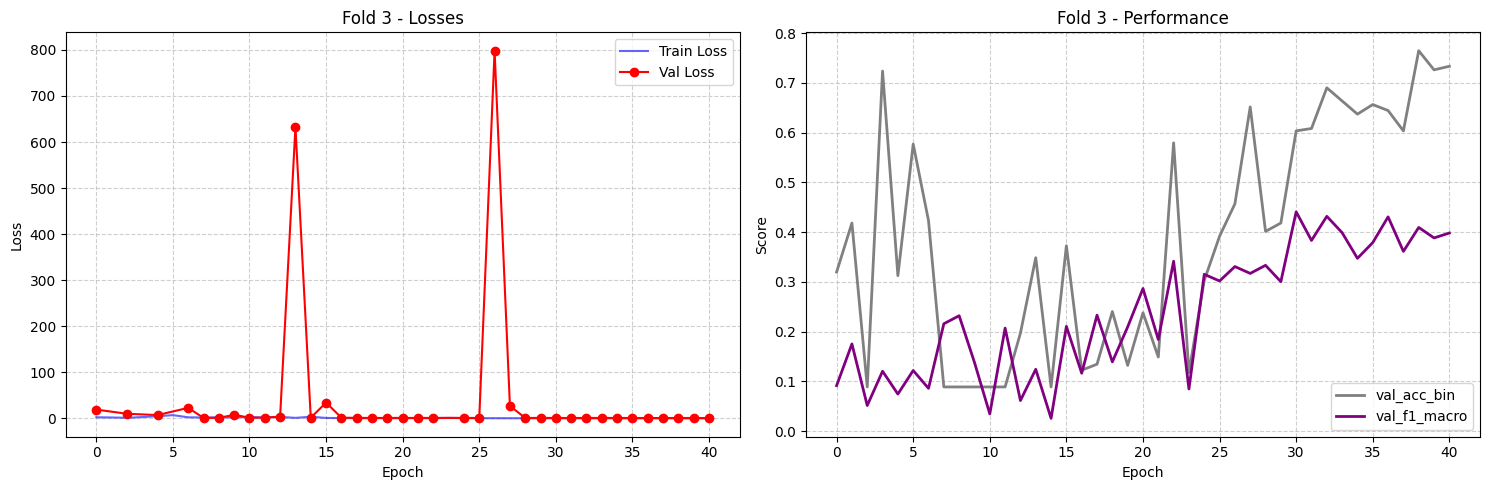


[00:32:24] --- Treinando Fold 4/5 ---


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_focal_loss_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


[00:34:23] 🧪 Avaliando melhor modelo do Fold 4...
[00:34:25] ✅ Fold 4 finalizado. Melhor Época: 3
[00:34:25] 🏆 Val F1 Macro (Best): 0.2137


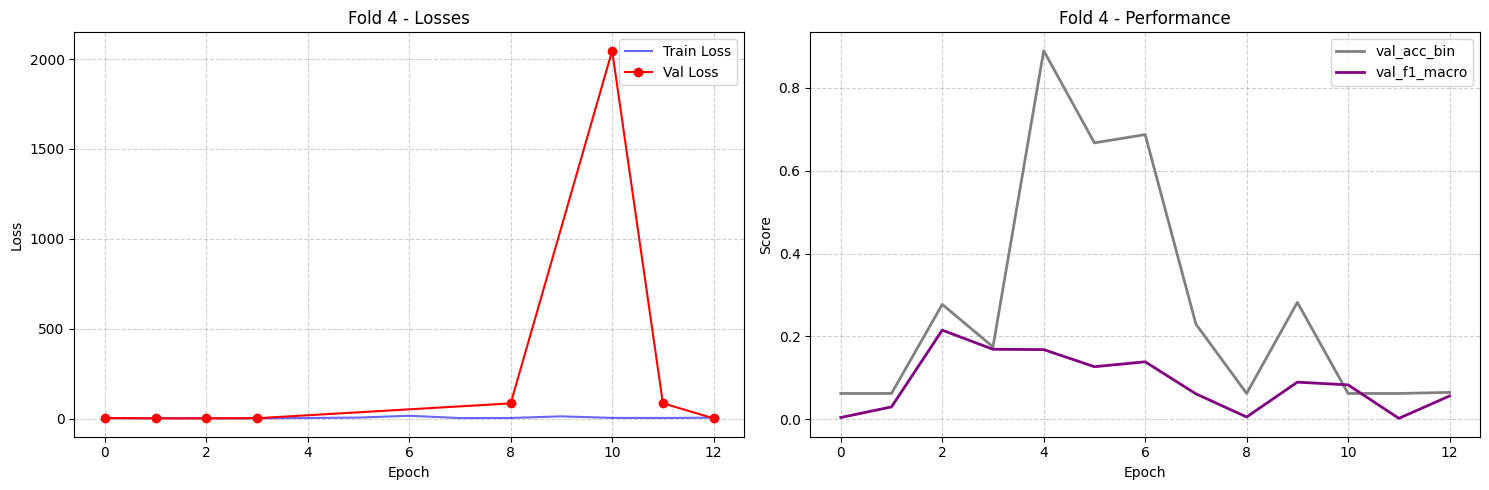


[00:34:26] --- Treinando Fold 5/5 ---


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_focal_loss_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


[00:37:47] 🧪 Avaliando melhor modelo do Fold 5...
[00:37:49] ✅ Fold 5 finalizado. Melhor Época: 12
[00:37:49] 🏆 Val F1 Macro (Best): 0.2931


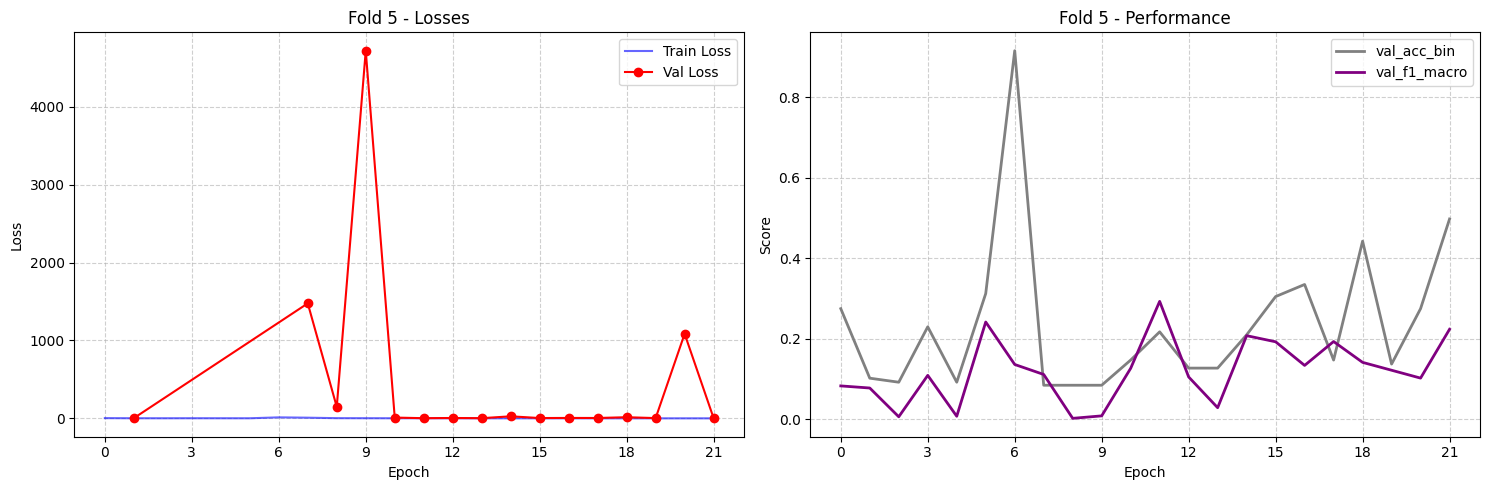


📊 RELATÓRIO DA VALIDAÇÃO CRUZADA (5 Folds)
🔸 F1 Macro          : 0.3756 ± 0.1126
🔸 F1 Weighted       : 0.8003 ± 0.0653
🔸 Precision Macro   : 0.3723 ± 0.1140
🔸 Recall Macro      : 0.4526 ± 0.1614
🔸 Binary Accuracy   : 0.7422 ± 0.1088


[00:37:50] 🌟 Folds concluídos! Mediana de Épocas: 8
[00:37:50] 🌟 Iniciando Treino do Modelo Final (Train + Val combinados)...


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_focal_loss_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` inste

[00:39:14] 📊 Gerando gráfico do Modelo Final...


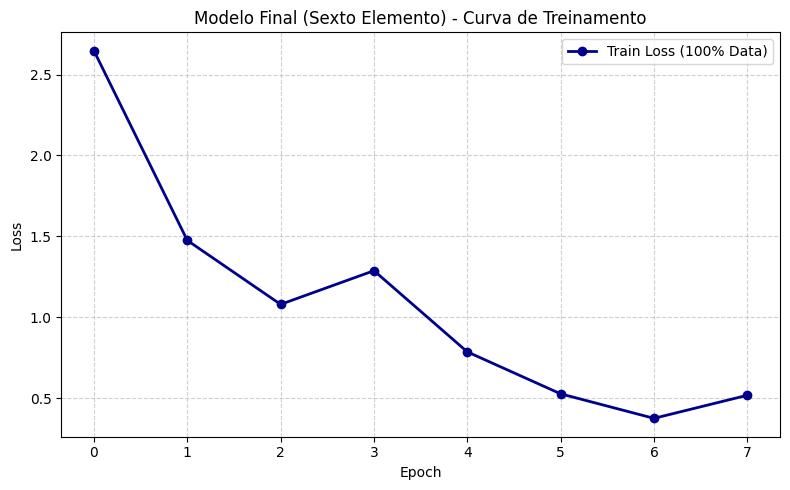


[00:39:14] 🚨 Carregando dados de Teste (Holdout)...

[00:39:14] 🔮 Extraindo predições do Holdout Test...

📊 RELATÓRIO DE CLASSIFICAÇÃO DETALHADO (HOLDOUT EXATO)
                 precision    recall  f1-score   support

           good       0.99      0.75      0.86       498
      brokenEnd       0.00      0.00      0.00         6
           hole       0.00      0.00      0.00         4
nettingMultiple       0.06      1.00      0.10         7
       thickBar       1.00      0.75      0.86         4
        thinBar       0.75      0.43      0.55         7
          knots       0.29      1.00      0.44         2

       accuracy                           0.74       528
      macro avg       0.44      0.56      0.40       528
   weighted avg       0.96      0.74      0.82       528



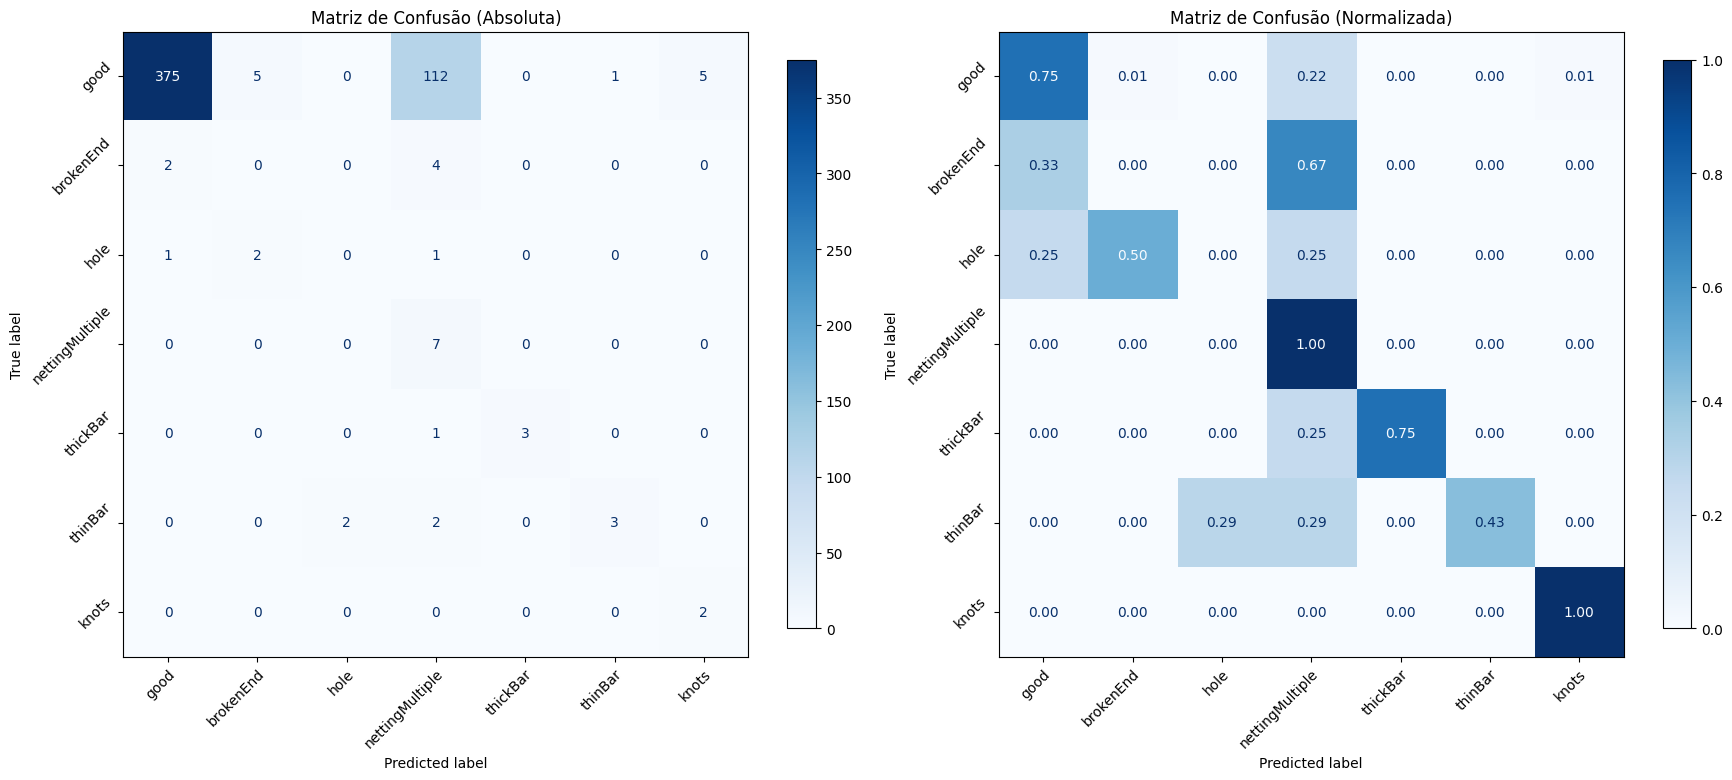


[00:39:16] 🎲 Iniciando Bootstrapping (1000 iterações)...

🏆 RESULTADOS FINAIS NO HOLDOUT (BOOTSTRAPPING - 95% CI) 🏆
🔹 F1 Macro          : 0.3852 (95% CI: [0.2577, 0.4749])  | Exato: 0.4011
🔹 F1 Weighted       : 0.8242 (95% CI: [0.7951, 0.8529])  | Exato: 0.8243
🔹 Precision Macro   : 0.4303 (95% CI: [0.2924, 0.5177])  | Exato: 0.4404
🔹 Recall Macro      : 0.5403 (95% CI: [0.3712, 0.6418])  | Exato: 0.5617
🔹 Binary Accuracy   : 0.7609 (95% CI: [0.7253, 0.7973])  | Exato: 0.7614


[2026-05-15 00:39:23] 🎉 EXPERIMENTO CONCLUÍDO! Tudo salvo em: ./experiments/HKU_64_focal_loss_mobilenetv3_large_150d.ra4_e3600_r256_in1k


In [11]:
DATASET = "HKU"
# DATASET = "TILDA"

# PSIZE = 32
PSIZE = 64
# PSIZE = 128

# MODEL_NAME = "fastvit_t8.apple_in1k"
MODEL_NAME = "mobilenetv3_large_150d.ra4_e3600_r256_in1k"
# MODEL_NAME = "resnet50.fb_swsl_ig1b_ft_in1k"

# EXPERIMENT_TYPE = "baseline"
# EXPERIMENT_TYPE = "undersampling"
EXPERIMENT_TYPE = "focal_loss"
# EXPERIMENT_TYPE = "wce"

UNDER_RATIO = None
# UNDER_RATIO = 1
# UNDER_RATIO = 5

set_seed(SEED)
run_lightning_experiment(dataset_name=DATASET, 
                         resolution=PSIZE, 
                         model_name=MODEL_NAME, 
                         experiment_type=EXPERIMENT_TYPE, 
                         undersample_ratio=UNDER_RATIO, 
                         num_epochs=N_EPOCHS, 
                         batch_size=BATCH_SIZE)

Seed set to 42


[00:39:23] Seed set as 42

[2026-05-15 00:39:23] 🚀 INICIANDO: HKU | 64px | mobilenetv3_large_150d.ra4_e3600_r256_in1k | WCE

[00:39:23] --- Treinando Fold 1/5 ---


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_wce_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ MobileNetV3        │ 13.4 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ multi_f1  │ MulticlassF1Score  │      0 │ train │     0 │
│ 3 │ multi_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 4 │ bin_f1    │ BinaryF1Score      │      0 │ train │     0 │
│ 5 │ bin_acc   │ BinaryAccuracy     │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 13.4 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 13.4 M                                                                                               
Total estimated model params size (MB): 53                                                                         
Modules in train mode: 412                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


[00:41:39] 🧪 Avaliando melhor modelo do Fold 1...
[00:41:41] ✅ Fold 1 finalizado. Melhor Época: 5
[00:41:41] 🏆 Val F1 Macro (Best): 0.2338


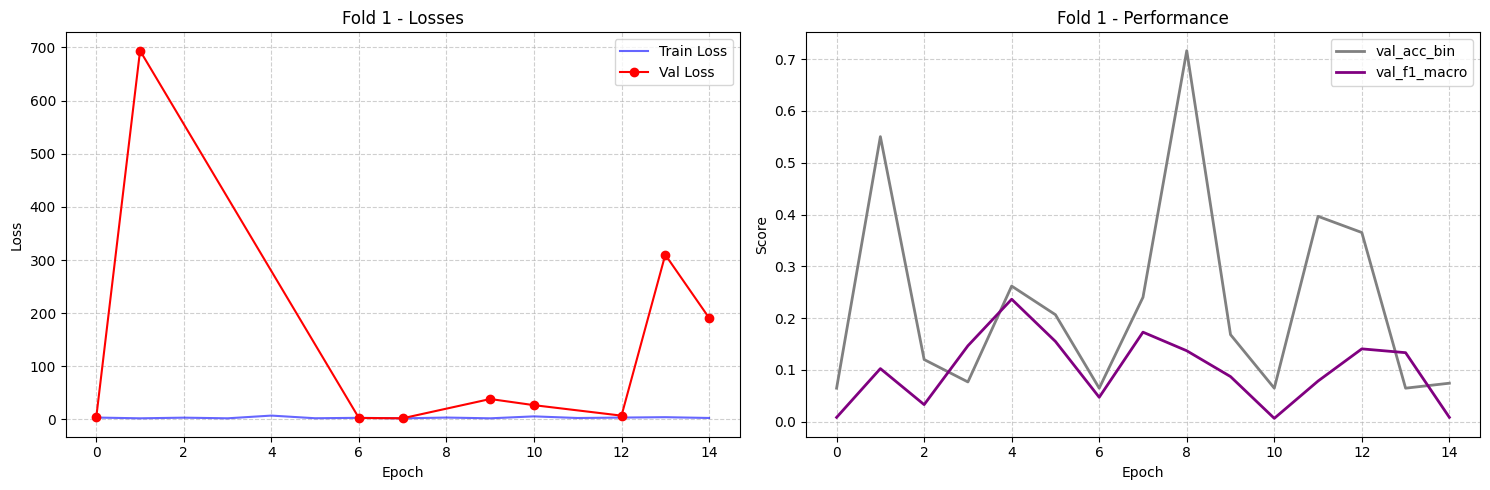


[00:41:42] --- Treinando Fold 2/5 ---


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_wce_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


[00:43:31] 🧪 Avaliando melhor modelo do Fold 2...
[00:43:33] ✅ Fold 2 finalizado. Melhor Época: 2
[00:43:33] 🏆 Val F1 Macro (Best): 0.2558


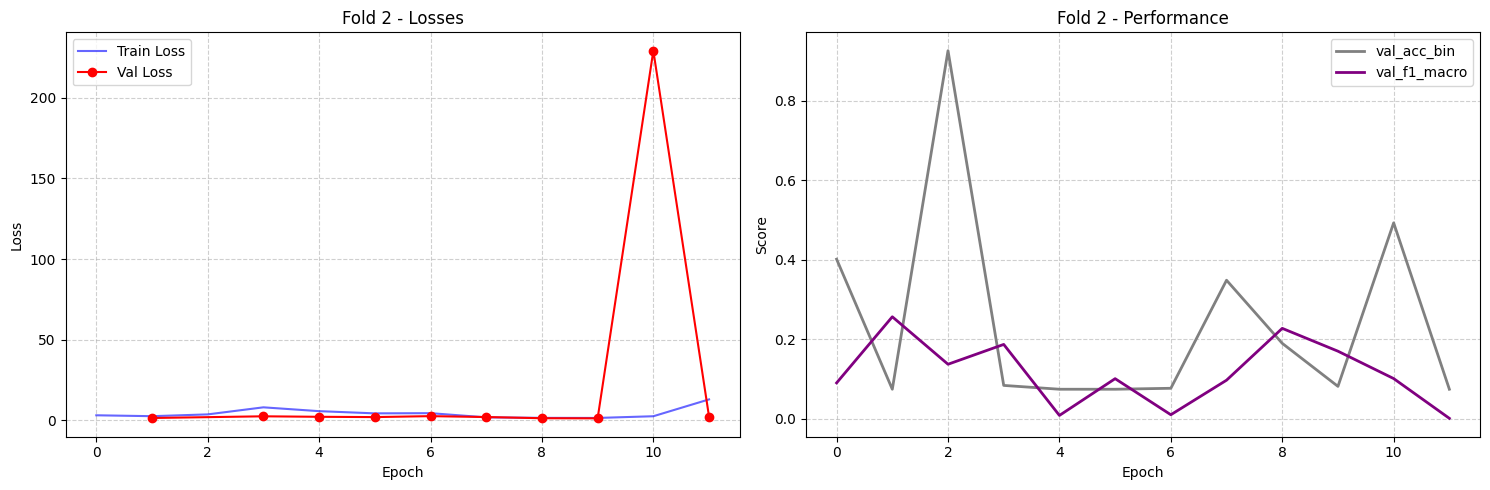


[00:43:34] --- Treinando Fold 3/5 ---


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_wce_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


[00:45:31] 🧪 Avaliando melhor modelo do Fold 3...
[00:45:33] ✅ Fold 3 finalizado. Melhor Época: 3
[00:45:33] 🏆 Val F1 Macro (Best): 0.2820


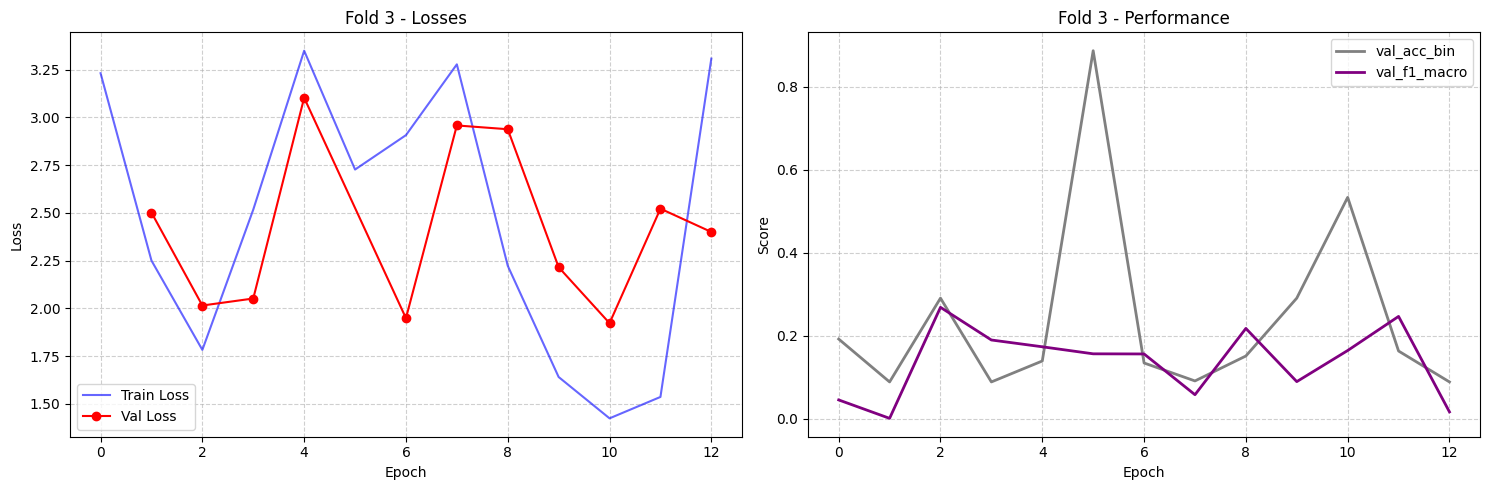


[00:45:34] --- Treinando Fold 4/5 ---


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_wce_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


[00:49:39] 🧪 Avaliando melhor modelo do Fold 4...
[00:49:41] ✅ Fold 4 finalizado. Melhor Época: 17
[00:49:41] 🏆 Val F1 Macro (Best): 0.3850


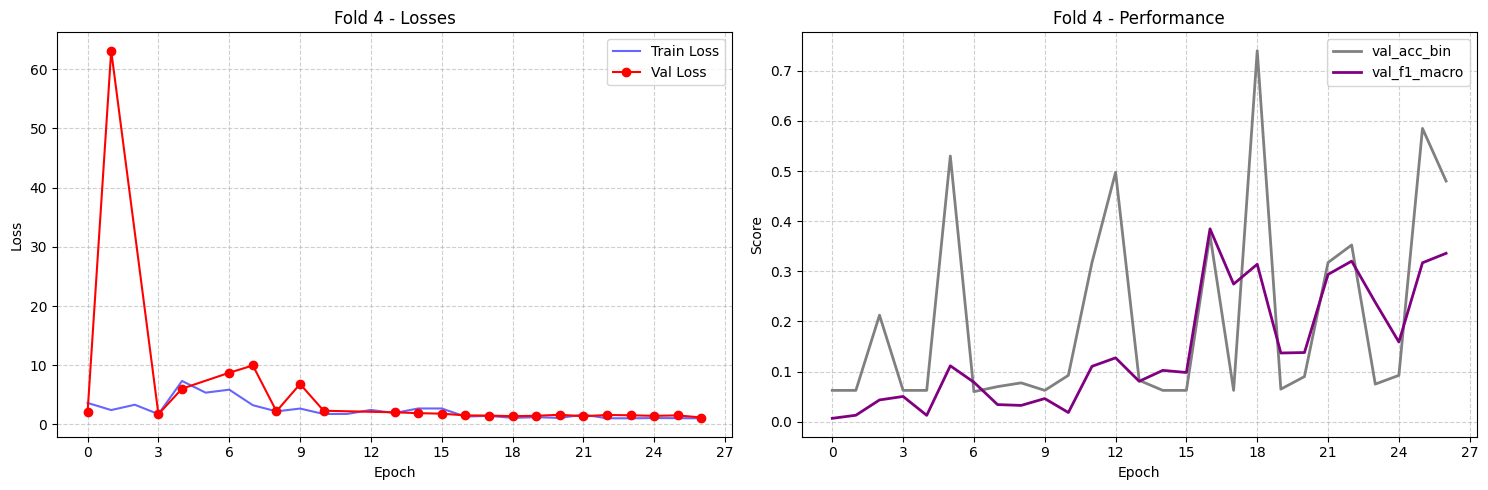


[00:49:42] --- Treinando Fold 5/5 ---


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_wce_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


[00:52:53] 🧪 Avaliando melhor modelo do Fold 5...
[00:52:55] ✅ Fold 5 finalizado. Melhor Época: 11
[00:52:55] 🏆 Val F1 Macro (Best): 0.1947


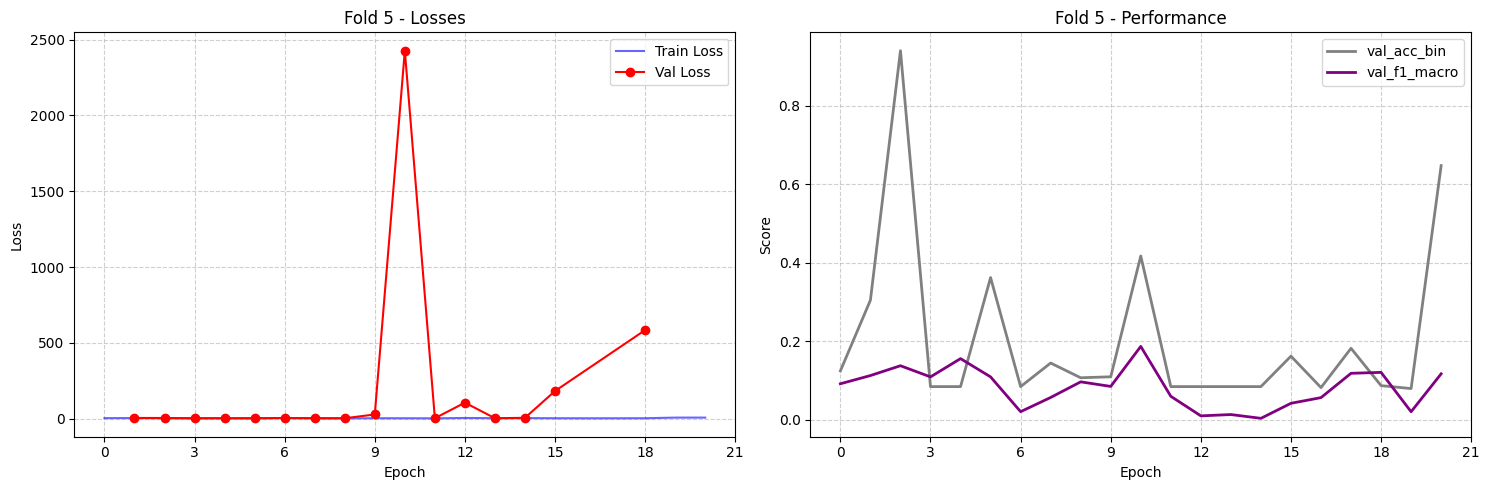


📊 RELATÓRIO DA VALIDAÇÃO CRUZADA (5 Folds)
🔸 F1 Macro          : 0.2703 ± 0.0641
🔸 F1 Weighted       : 0.6324 ± 0.2096
🔸 Precision Macro   : 0.3447 ± 0.1021
🔸 Recall Macro      : 0.3018 ± 0.0414
🔸 Binary Accuracy   : 0.5626 ± 0.1959


[00:52:56] 🌟 Folds concluídos! Mediana de Épocas: 5
[00:52:56] 🌟 Iniciando Treino do Modelo Final (Train + Val combinados)...


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/HKU_64_wce_mobilenetv3_large_150d.ra4_e3600_r256_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
`Tr

[00:53:49] 📊 Gerando gráfico do Modelo Final...


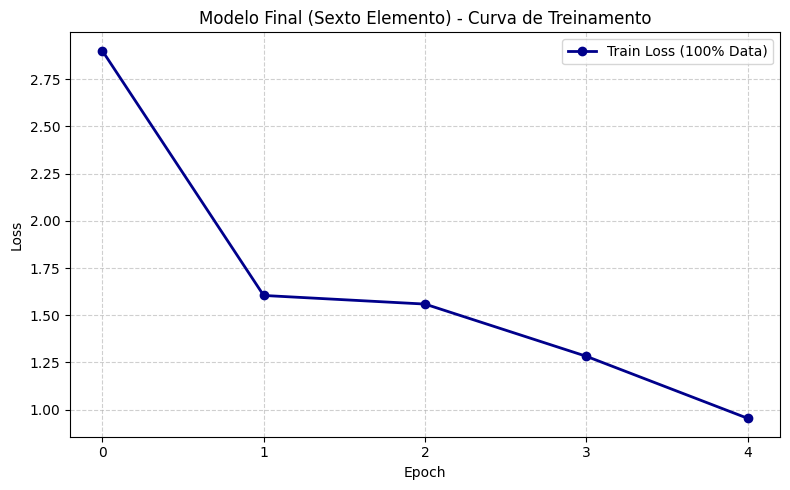


[00:53:49] 🚨 Carregando dados de Teste (Holdout)...

[00:53:49] 🔮 Extraindo predições do Holdout Test...

📊 RELATÓRIO DE CLASSIFICAÇÃO DETALHADO (HOLDOUT EXATO)
                 precision    recall  f1-score   support

           good       0.97      0.91      0.94       498
      brokenEnd       0.00      0.00      0.00         6
           hole       0.00      0.00      0.00         4
nettingMultiple       0.08      0.29      0.12         7
       thickBar       0.40      1.00      0.57         4
        thinBar       0.18      0.43      0.25         7
          knots       1.00      1.00      1.00         2

       accuracy                           0.88       528
      macro avg       0.38      0.52      0.41       528
   weighted avg       0.93      0.88      0.90       528



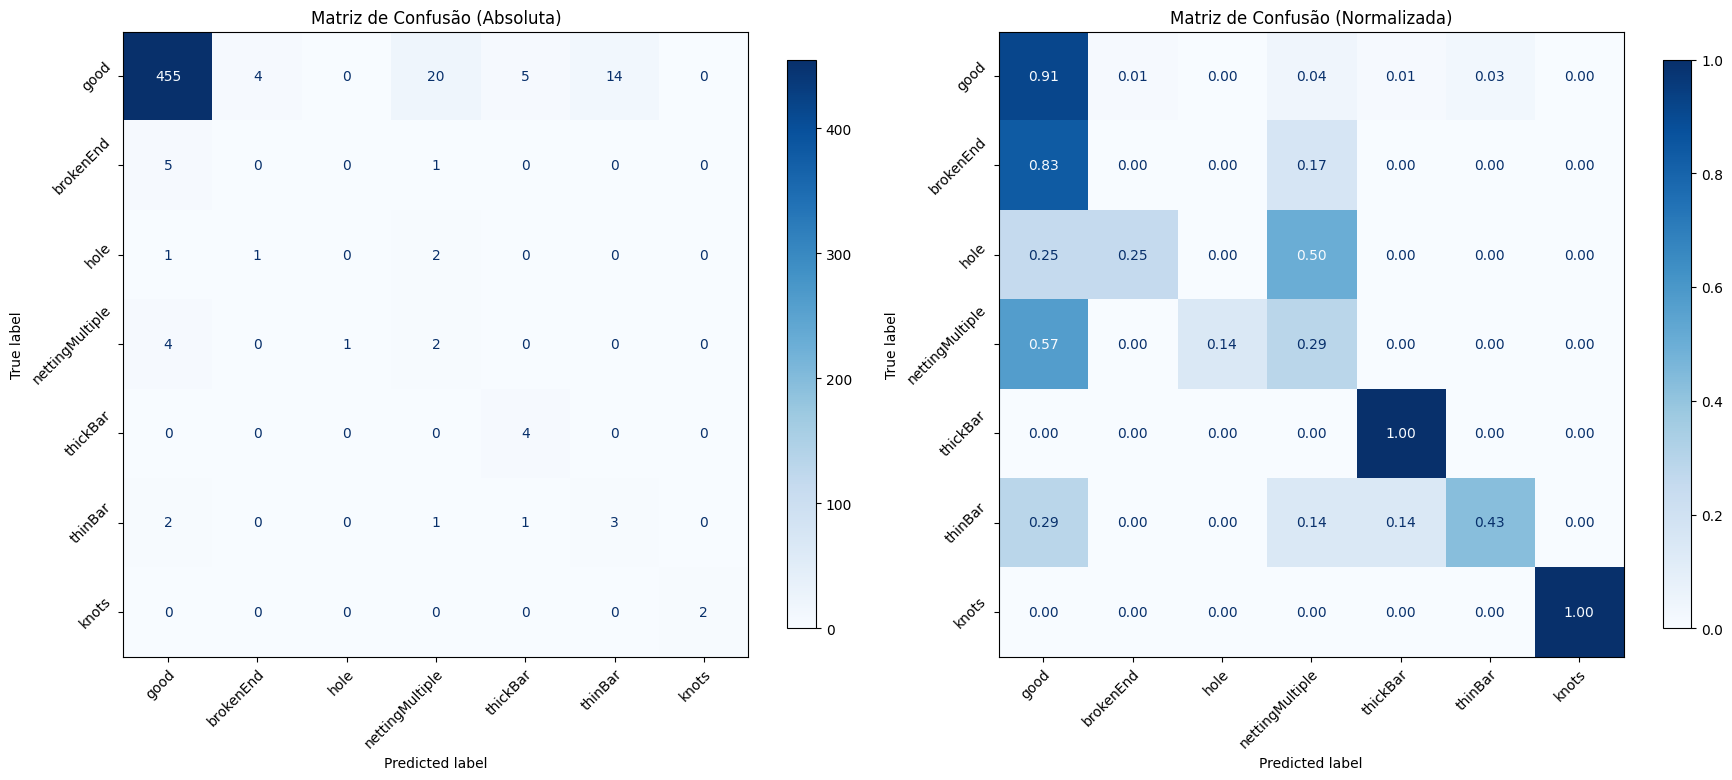


[00:53:51] 🎲 Iniciando Bootstrapping (1000 iterações)...

🏆 RESULTADOS FINAIS NO HOLDOUT (BOOTSTRAPPING - 95% CI) 🏆
🔹 F1 Macro          : 0.3943 (95% CI: [0.2756, 0.4705])  | Exato: 0.4122
🔹 F1 Weighted       : 0.9032 (95% CI: [0.8784, 0.9256])  | Exato: 0.9025
🔹 Precision Macro   : 0.3611 (95% CI: [0.2429, 0.4328])  | Exato: 0.3754
🔹 Recall Macro      : 0.5057 (95% CI: [0.3778, 0.5976])  | Exato: 0.5183
🔹 Binary Accuracy   : 0.8956 (95% CI: [0.8693, 0.9205])  | Exato: 0.8958


[2026-05-15 00:53:58] 🎉 EXPERIMENTO CONCLUÍDO! Tudo salvo em: ./experiments/HKU_64_wce_mobilenetv3_large_150d.ra4_e3600_r256_in1k


In [12]:
DATASET = "HKU"
# DATASET = "TILDA"

# PSIZE = 32
PSIZE = 64
# PSIZE = 128

# MODEL_NAME = "fastvit_t8.apple_in1k"
MODEL_NAME = "mobilenetv3_large_150d.ra4_e3600_r256_in1k"
# MODEL_NAME = "resnet50.fb_swsl_ig1b_ft_in1k"

# EXPERIMENT_TYPE = "baseline"
# EXPERIMENT_TYPE = "undersampling"
# EXPERIMENT_TYPE = "focal_loss"
EXPERIMENT_TYPE = "wce"

UNDER_RATIO = None
# UNDER_RATIO = 1
# UNDER_RATIO = 5

set_seed(SEED)
run_lightning_experiment(dataset_name=DATASET, 
                         resolution=PSIZE, 
                         model_name=MODEL_NAME, 
                         experiment_type=EXPERIMENT_TYPE, 
                         undersample_ratio=UNDER_RATIO, 
                         num_epochs=N_EPOCHS, 
                         batch_size=BATCH_SIZE)